# Spike coordination in simultaneously recorded neural pairs

Does spike coordination between two simultaneously recorded neurons differ
between **interactive-face**, **non-interactive-face** and **object** fixations
— within a region, and across regions?

## What is computed

Every cross-correlation is computed on one fixation's two **unsmoothed 1 ms**
spike trains, over the **±500 ms** window around fixation onset, and only then
averaged across fixations. Nothing outside that window enters anything.

The correlation is **linear** (zero-padded), the same statistic
`scipy.signal.correlate` computes. Values are **coincidences per fixation**:
spike pairs at that lag, averaged over fixations. No normalisation is applied —
the null already carries both units' firing rates and exact spike counts, so
`observed − null` is rate-controlled by construction.

## The null

One null, the **circular shift**: unit B's train is rotated by a random offset
(at least 50 ms) **within its own fixation**. Each fixation keeps its own spike
counts and its slow envelope, so two cells whose excitability simply rises and
falls together across fixations produce *no* excess over it. What is destroyed
is fine temporal alignment.

This replaces the cross-trial shuffle, which pairs fixation *i* with fixation
*j* and so destroys across-fixation rate covariation as well — too low a bar. A
synthetic pair with shared gain and no timing relationship reaches z = 2.0
against the cross-trial null and 1.3 against this one, level with an uncoupled
pair.

**Known bias, stated up front.** The rotation also misaligns the two units'
*fixation-locked rate profiles*. Two cells that both respond to fixation onset
show a broad correlation from that alone, and the shift removes it — so the null
sits low at every lag and a uniform positive excess appears with no timing
structure behind it. On a synthetic uncoupled pair with a shared rate bump this
bias is about z = 1.2. Read the **shape** of the excess, not its offset: a peak
standing above its own flanks is coordination, a flat elevation is this bias.

## Structure

Per region, per fixation type. **Nothing is averaged across regions.**

1. Within region — all pairs
2. Within region — FDR-selective pairs
3. Across regions — all pairs
4. Across regions — FDR-selective pairs

Each block shows the observed correlation against the null, then the
null-corrected difference with the condition contrasts.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_spike_coordination as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

cfg = load_config(str(repo_root / "configs" / "dataset.yaml"))
settings = psc.build_pair_spike_coordination_settings_from_config(
    dataset_cfg_path=str(repo_root / "configs" / "dataset.yaml"),
    coordination_cfg_path=str(repo_root / "configs" / "ephys_fixation_pair_spike_coordination.yaml"),
)

SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairCoordinationPlotSettings(output_dir=FIGURE_DIR)
MIN_PAIRS = psc.DEFAULT_MIN_PAIRS_FOR_REPORTING

print(f"window        : {settings.signal_window_ms[0]:.0f} to {settings.signal_window_ms[1]:.0f} ms")
print(f"signal        : {settings.signal_input_column} from {settings.trial_input_filename}")
print(f"null          : {settings.n_circular_shift_draws} circular shifts, min {settings.min_circular_shift_ms:.0f} ms")

window        : -500 to 500 ms
signal        : spike_train_counts from fixations_spike_train_1ms.pkl
null          : 50 circular shifts, min 50 ms


## Build state and summaries

In [2]:
# Submission is opt-in: the array costs cluster time and a cell is easy to
# re-run by accident. False only reports what is missing.
SUBMIT_JOBS = False
REBUILD_SUMMARIES = True

per_date = psc.ensure_pair_coordination_built(
    settings, submit=SUBMIT_JOBS, wait=True,
    sbatch_path=repo_root / psc.DEFAULT_SBATCH_PATH, repo_root=repo_root,
)
if REBUILD_SUMMARIES:
    _ = psc.run_summary_build(settings)

dates: 42 total, 42 complete, 0 incomplete
sessions: 417 of 417 built (11.00 GB on disk)
nothing to build.


dropped 1 artifact date(s): ['09292018']
pairs retained: 437,605 of 446,414


summary tables written to /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary


## What the recordings support

A cross-region pair exists only where both regions were recorded in the **same
session**. All four regions support within-region comparisons; across regions
every well-populated combination involves BLA. Combinations below the pair
threshold appear in the table but are excluded from the figures.

Days carrying the zero-lag artifact are removed from everything below.

In [3]:
traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region.pkl")
traces_sig = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")
contrasts = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region.csv")
contrasts_sig = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region_selective.csv")

# Confirm every cross-correlation came from the same +/-500 ms window.
one = next(
    (build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR)).glob(
        "date=*/session=*/pair_coordination.pkl"
    )
)
meta = pd.read_pickle(one)["meta"]
print(f"window {meta['signal_window_ms']} ms at {meta['bin_size_ms']:.0f} ms bins, "
      f"{meta['correlation_kind']} correlation, null = {meta['null_kind']}")

display(pd.read_csv(SUMMARY_DIR / "region_pair_inventory.csv"))

window (-500.0, 500.0) ms at 1 ms bins, linear correlation, null = circular shift: rotation within the analysis window


,scope,region_pair,n_pairs,n_pairs_both_selective,n_sessions,n_dates,min_pairs_per_condition,n_conditions,sufficient_pairs,sufficient_selective_pairs
0,cross_region,bla-dmpfc,78711,19309,150,15,23288,3,True,True
1,cross_region,accg-bla,54182,15794,137,14,14756,3,True,True
2,cross_region,bla-ofc,51217,12476,110,11,15393,3,True,True
3,cross_region,accg-dmpfc,11771,730,89,9,3250,3,True,True
4,cross_region,dmpfc-ofc,304,0,10,1,84,3,False,False
5,within_region,bla,106697,39958,337,34,29677,3,True,True
6,within_region,ofc,56541,13846,129,13,17559,3,True,True
7,within_region,accg,42348,6965,186,19,12053,3,True,True
8,within_region,dmpfc,35834,7054,150,15,10097,3,True,True


# 1. Within region — all pairs

## Observed correlation and the cross-trial null

Regions down, fixation conditions across. The **gap between the curves** is the
coordination; the observed curve alone is not, since a correlation scales with
the product of the two firing rates.

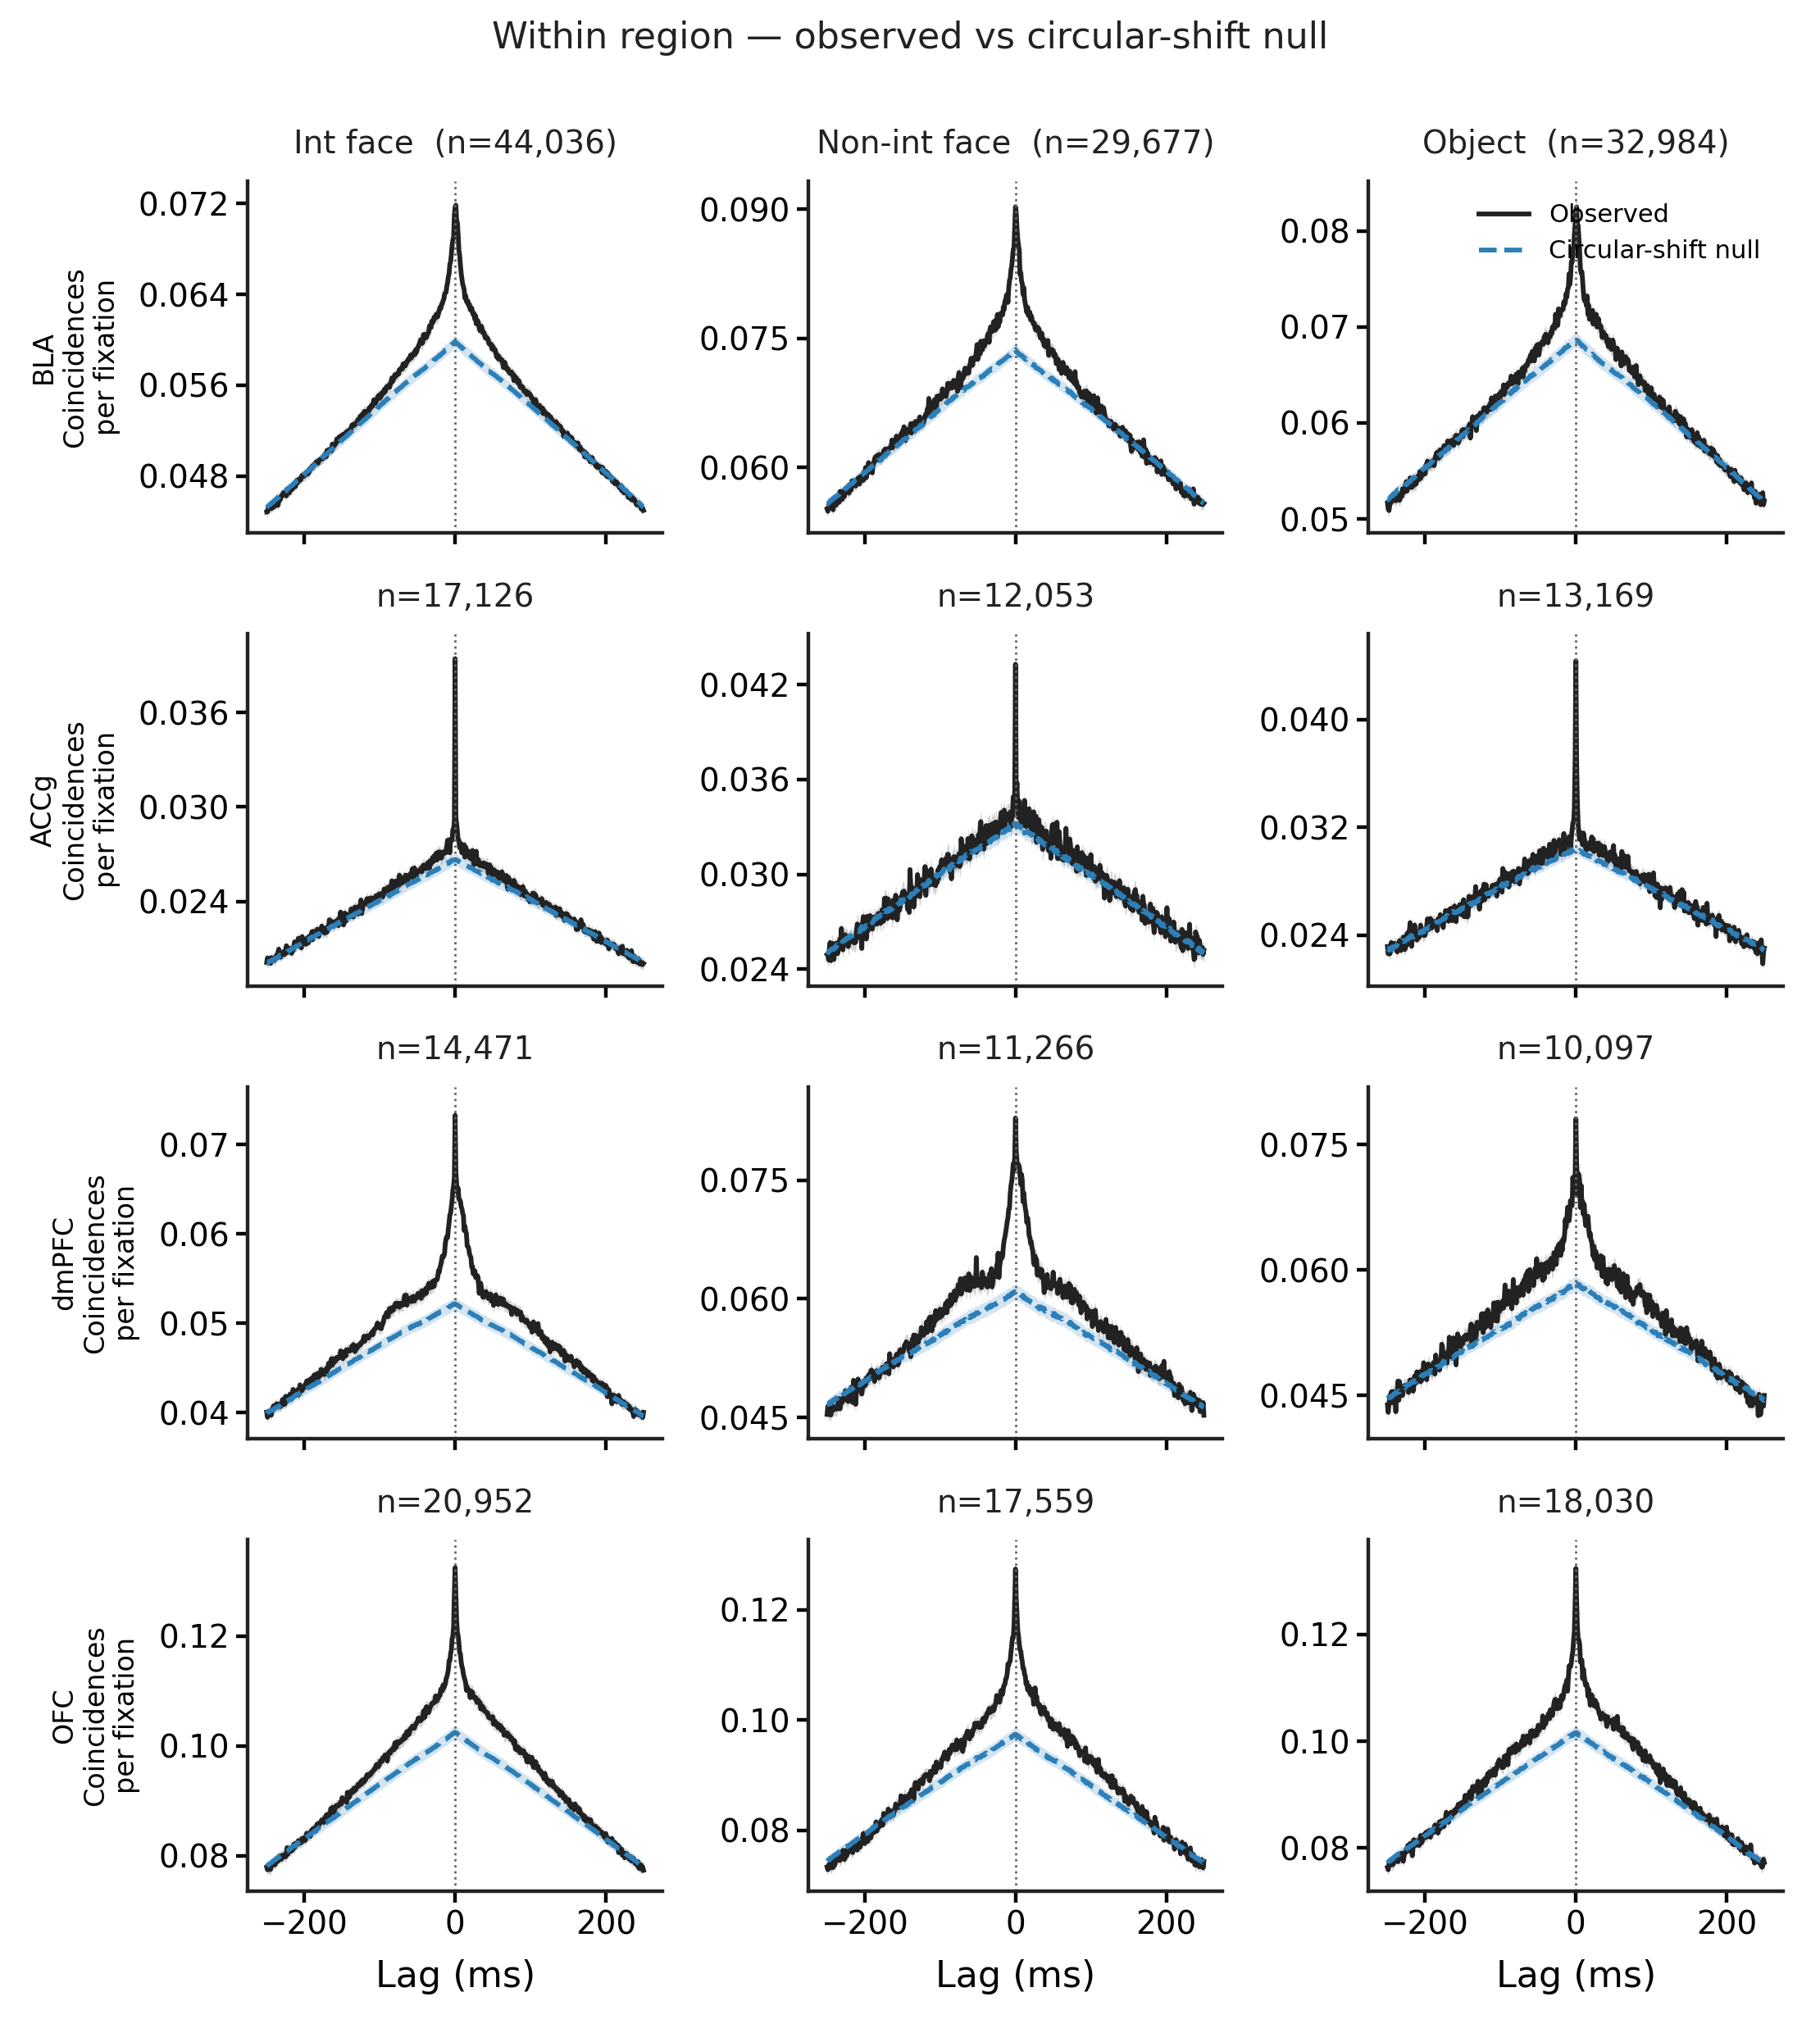

In [4]:
fig, paths = viz.plot_observed_and_null_grid(
    traces, figs, scope="within_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

## Null-corrected, and condition comparisons

Observed minus null, conditions overlaid within each region. Zero means no
coordination beyond what each unit's own fixation-locked rate profile predicts.

Contrasts are **paired within pair** — the same two neurons, electrodes and
session, differing only in which fixations were used. Benjamini–Hochberg
corrected; filled markers survived it.

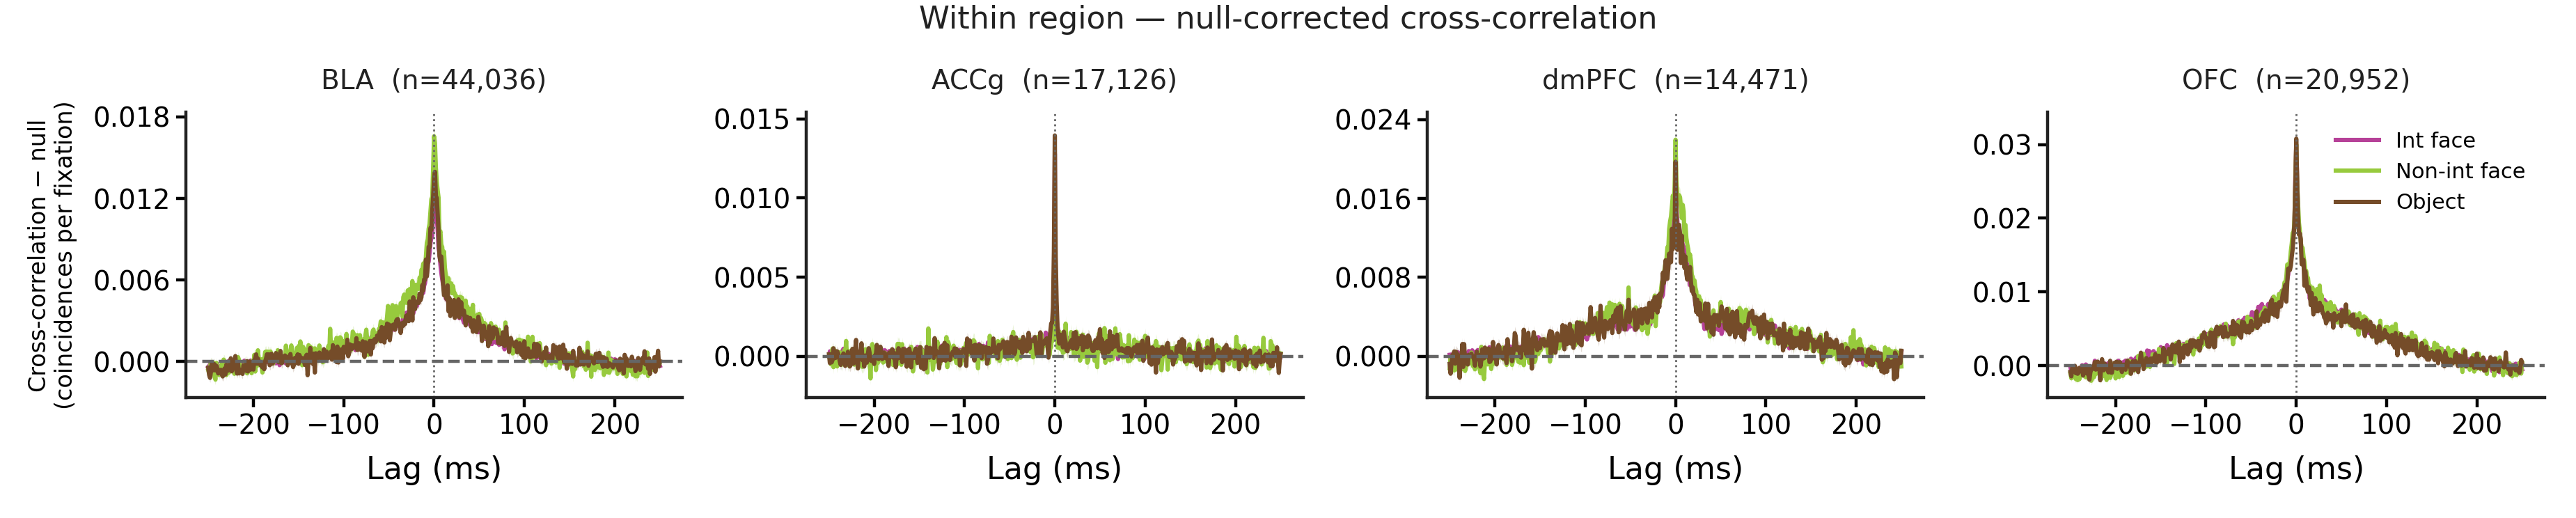

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
15,within_region,accg,face_interactive,face_non_interactive,12029,0.0026,0.0015,0.0011,31436340.0,0.0000,0.1256,0.0000,True,fdr_bh
16,within_region,accg,face_interactive,object,13052,0.0025,0.0026,-0.0001,40516843.5,0.0000,0.0760,0.0000,True,fdr_bh
17,within_region,accg,face_non_interactive,object,10549,0.0017,0.0030,-0.0013,25789819.5,0.0000,-0.0427,0.0000,True,fdr_bh
18,within_region,bla,face_interactive,face_non_interactive,29517,0.0116,0.0114,0.0002,204565720.5,0.0000,0.0796,0.0000,True,fdr_bh
19,within_region,bla,face_interactive,object,32716,0.0101,0.0096,0.0005,245508915.5,0.0000,0.0827,0.0000,True,fdr_bh
20,within_region,bla,face_non_interactive,object,24587,0.0120,0.0116,0.0005,148684321.0,0.0284,0.0018,0.0383,True,fdr_bh
21,within_region,dmpfc,face_interactive,face_non_interactive,11168,0.0149,0.0154,-0.0005,29685307.5,0.0000,0.0763,0.0000,True,fdr_bh
22,within_region,dmpfc,face_interactive,object,10073,0.0151,0.0116,0.0035,21090798.0,0.0000,0.1353,0.0000,True,fdr_bh
23,within_region,dmpfc,face_non_interactive,object,8722,0.0175,0.0124,0.0051,16867067.0,0.0000,0.0600,0.0000,True,fdr_bh
24,within_region,ofc,face_interactive,face_non_interactive,17532,0.0193,0.0182,0.0011,70661276.5,0.0000,0.0906,0.0000,True,fdr_bh


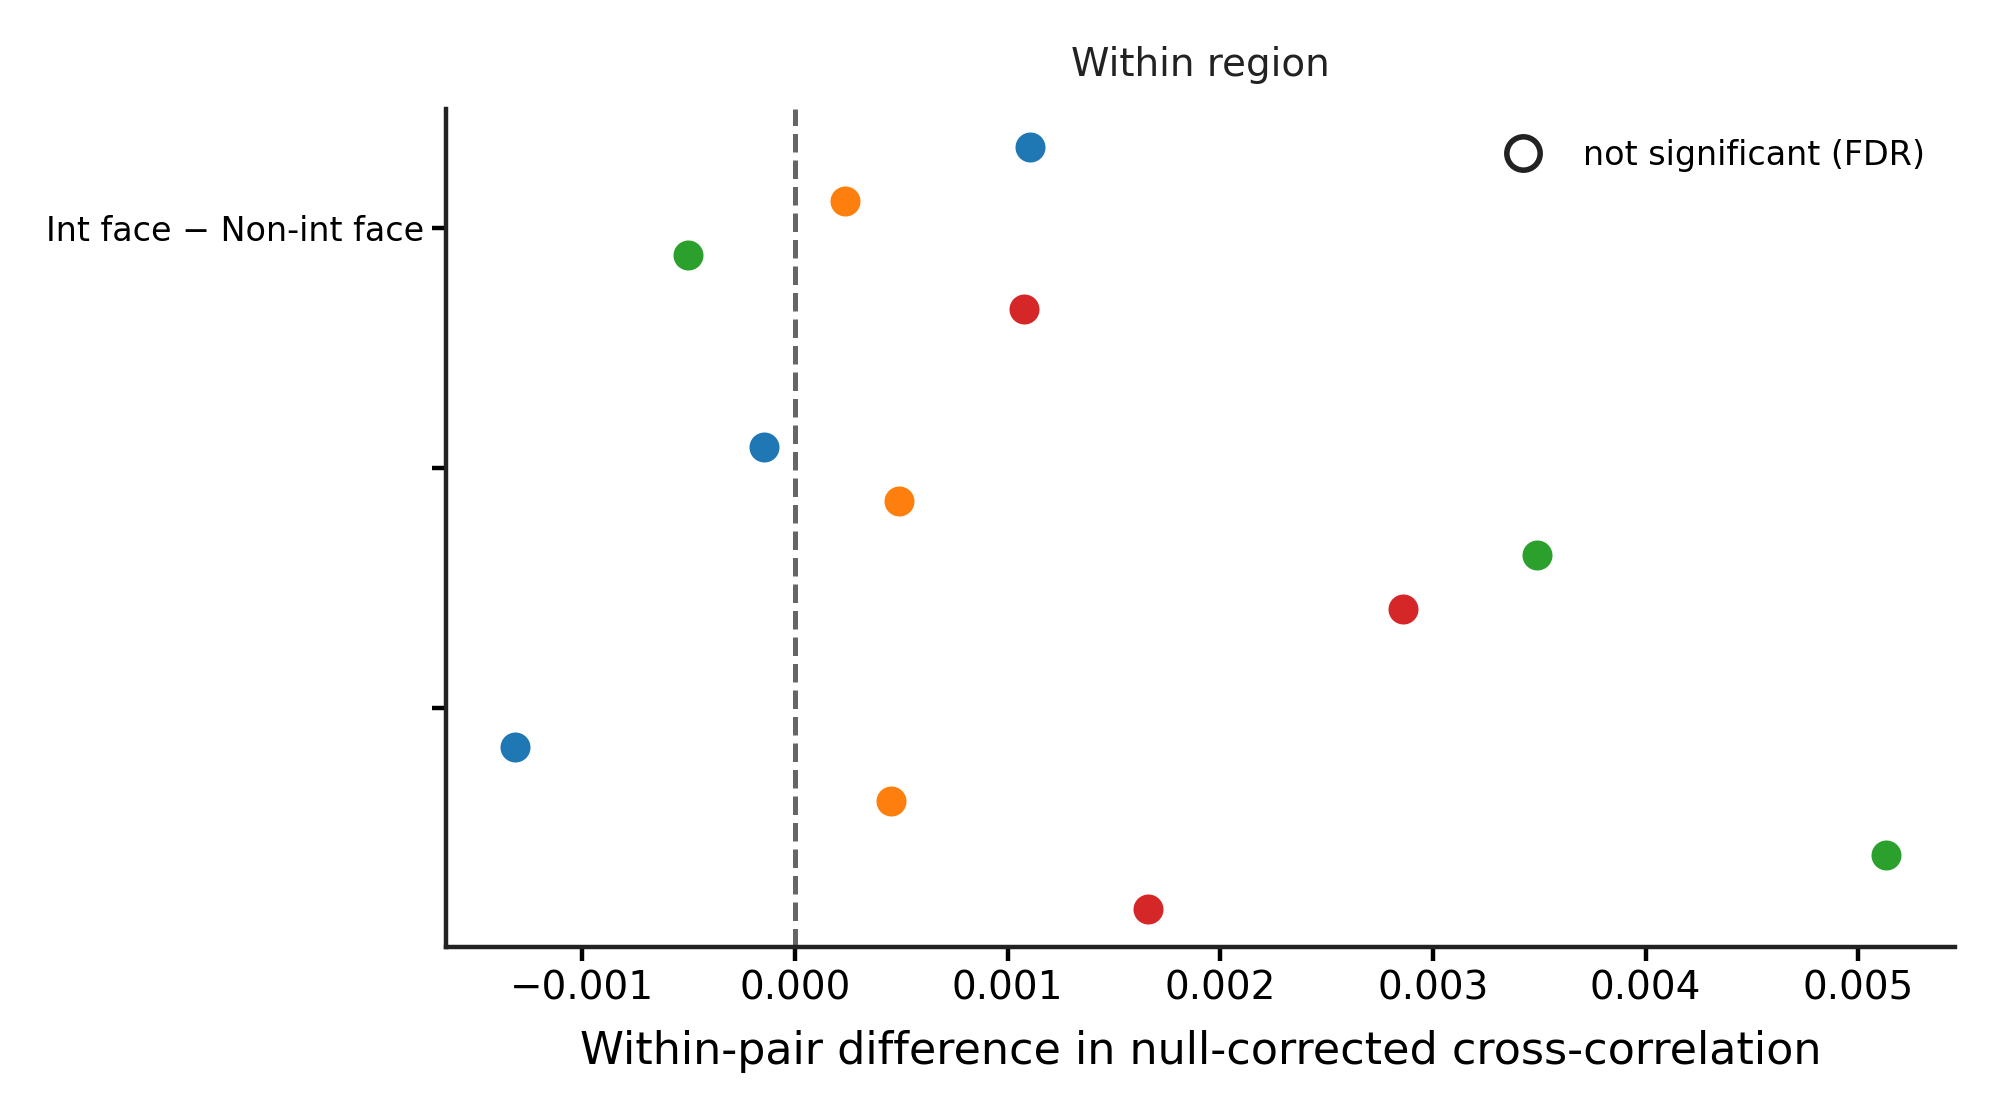

In [5]:
fig, paths = viz.plot_null_corrected_grid(
    traces, figs, scope="within_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

subset = contrasts.loc[contrasts["scope"] == "within_region"]
display(subset.round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts, figs, scope="within_region"
)
display(Image(filename=str(paths["png"])))

# 2. Within region — FDR-selective pairs

Pairs where **both** units are significantly selective for at least one
fixation-condition contrast (FDR-corrected, `three_condition_core`).

Selecting units by a condition contrast and then asking whether coordination
differs by condition is circular, so this is a sensitivity check rather than
independent confirmation. What it can show is whether an effect is carried by
the selective subset or is distributed across the population.

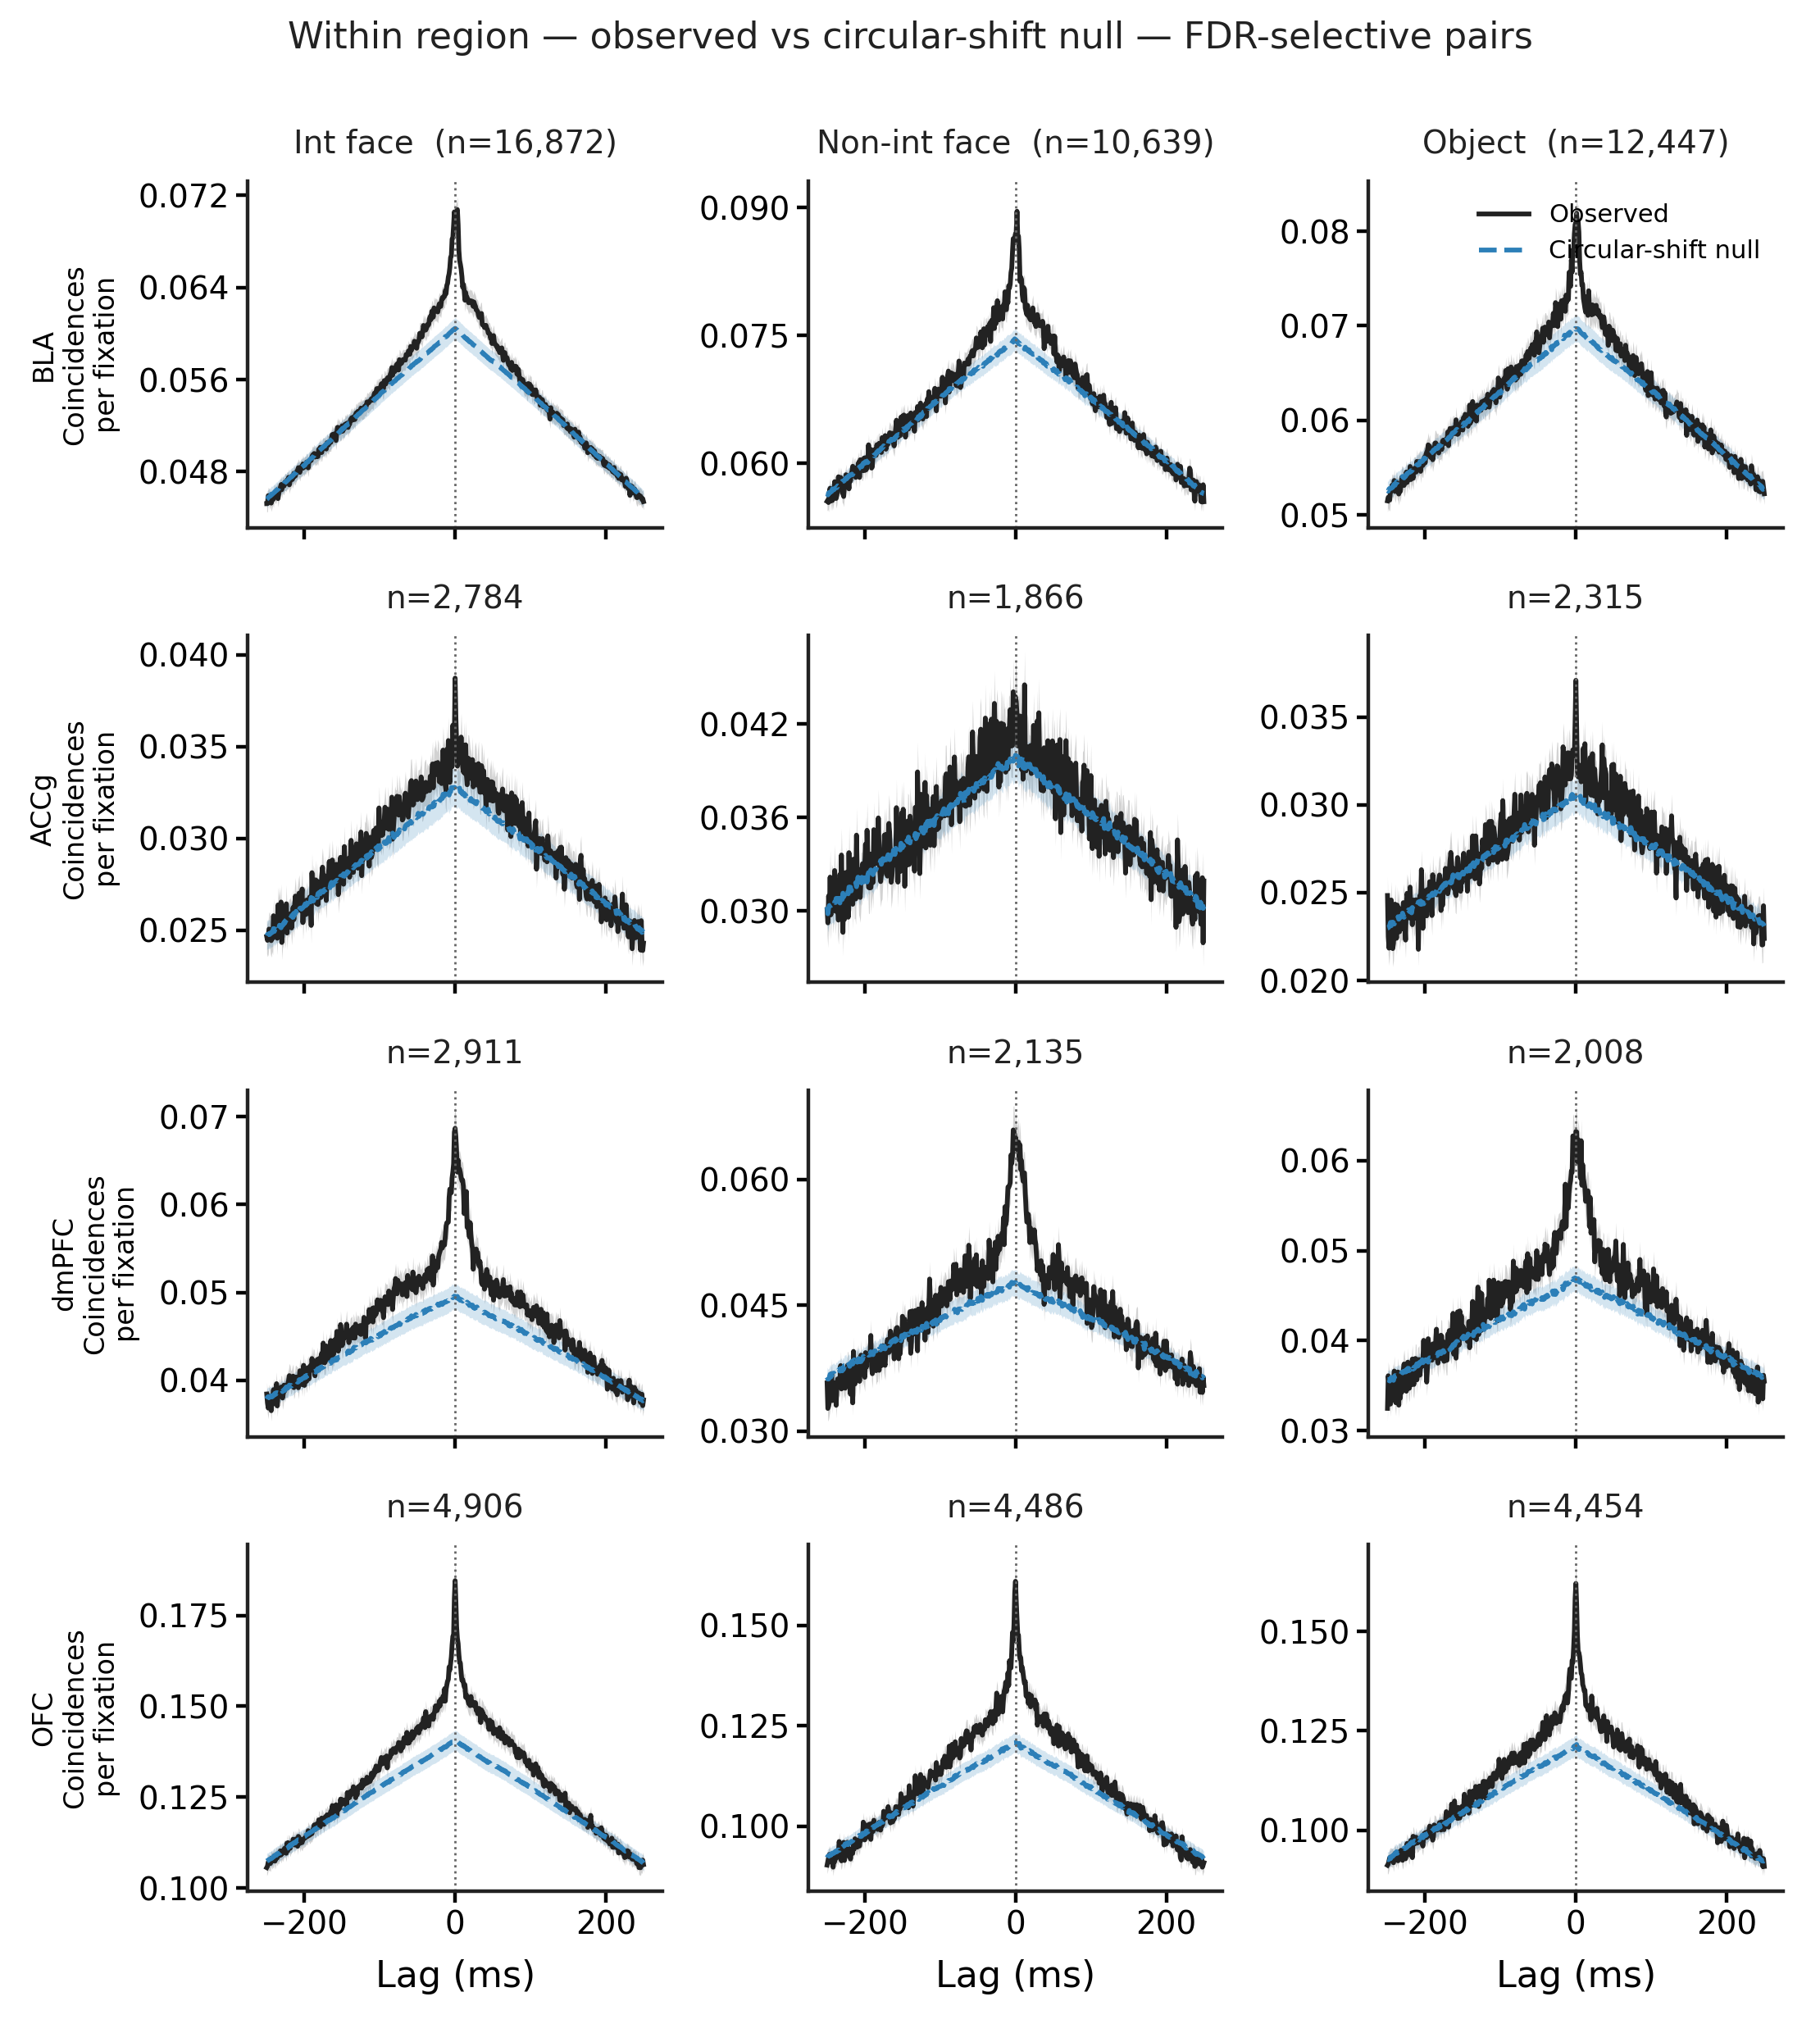

In [6]:
fig, paths = viz.plot_observed_and_null_grid(
    traces_sig, figs, scope="within_region", min_pairs=MIN_PAIRS, label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

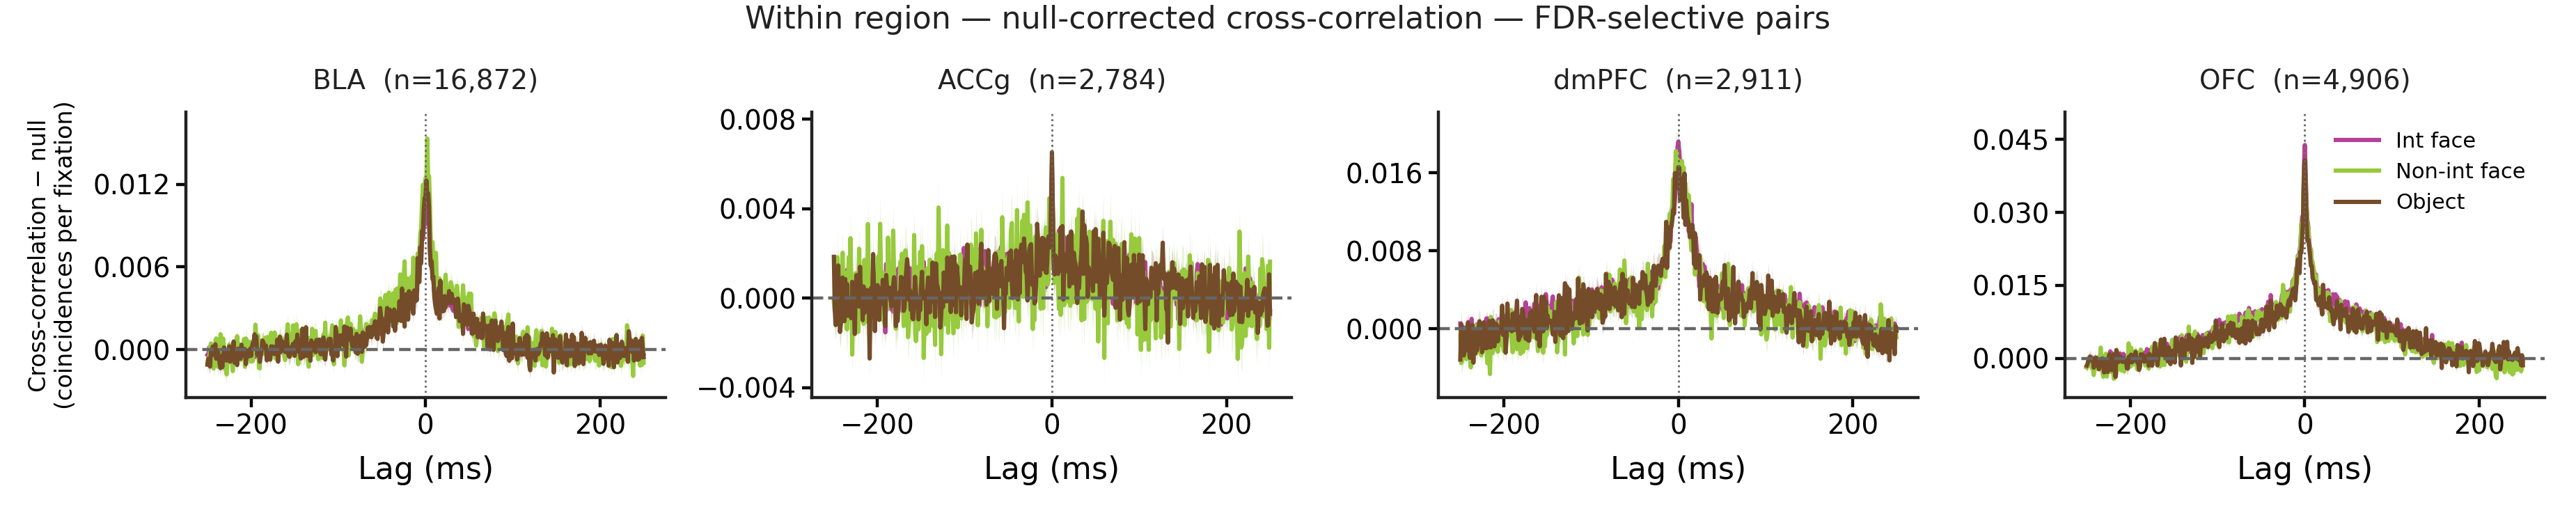

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
12,within_region,accg,face_interactive,face_non_interactive,1865,0.0027,0.0020,0.0007,799929.0,0.0026,0.0928,0.0062,True,fdr_bh
13,within_region,accg,face_interactive,object,2290,0.0025,0.0023,0.0002,1261784.0,0.1155,0.0384,0.1539,False,fdr_bh
14,within_region,accg,face_non_interactive,object,1726,0.0021,0.0027,-0.0006,710372.5,0.0926,-0.0452,0.1307,False,fdr_bh
15,within_region,bla,face_interactive,face_non_interactive,10620,0.0105,0.0099,0.0005,26141475.0,0.0000,0.0906,0.0000,True,fdr_bh
16,within_region,bla,face_interactive,object,12384,0.0088,0.0082,0.0006,34200062.0,0.0000,0.1001,0.0000,True,fdr_bh
17,within_region,bla,face_non_interactive,object,8734,0.0106,0.0102,0.0004,18430647.0,0.0064,0.0117,0.0128,True,fdr_bh
18,within_region,dmpfc,face_interactive,face_non_interactive,2097,0.0174,0.0155,0.0019,973270.0,0.0000,0.1216,0.0000,True,fdr_bh
19,within_region,dmpfc,face_interactive,object,2008,0.0181,0.0136,0.0045,824354.0,0.0000,0.1444,0.0000,True,fdr_bh
20,within_region,dmpfc,face_non_interactive,object,1609,0.0174,0.0141,0.0033,629132.5,0.3423,-0.0087,0.4120,False,fdr_bh
21,within_region,ofc,face_interactive,face_non_interactive,4486,0.0284,0.0255,0.0029,4477206.0,0.0000,0.0981,0.0000,True,fdr_bh


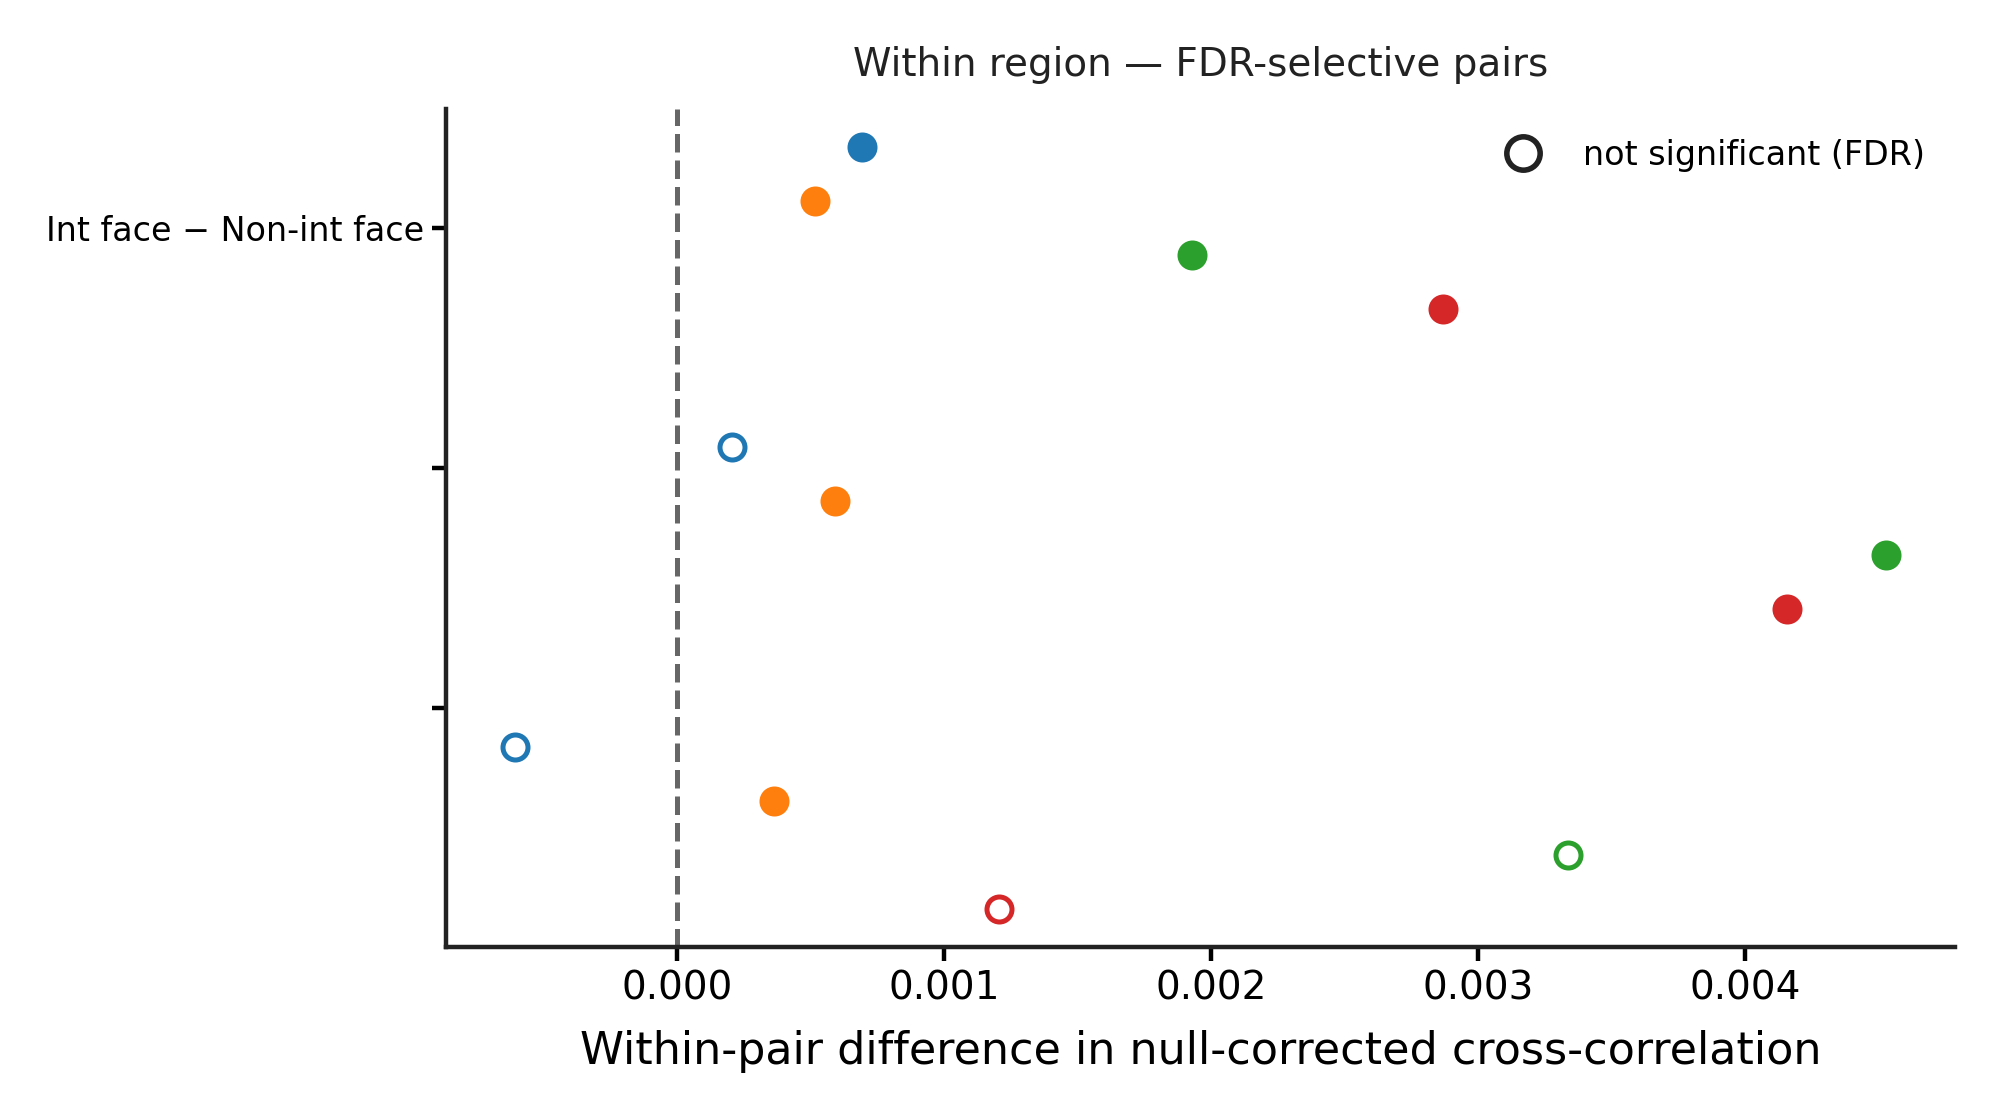

In [7]:
fig, paths = viz.plot_null_corrected_grid(
    traces_sig, figs, scope="within_region", min_pairs=MIN_PAIRS, label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

subset = contrasts_sig.loc[contrasts_sig["scope"] == "within_region"]
display(subset.round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts_sig, figs, scope="within_region", label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

# 3. Across regions — all pairs

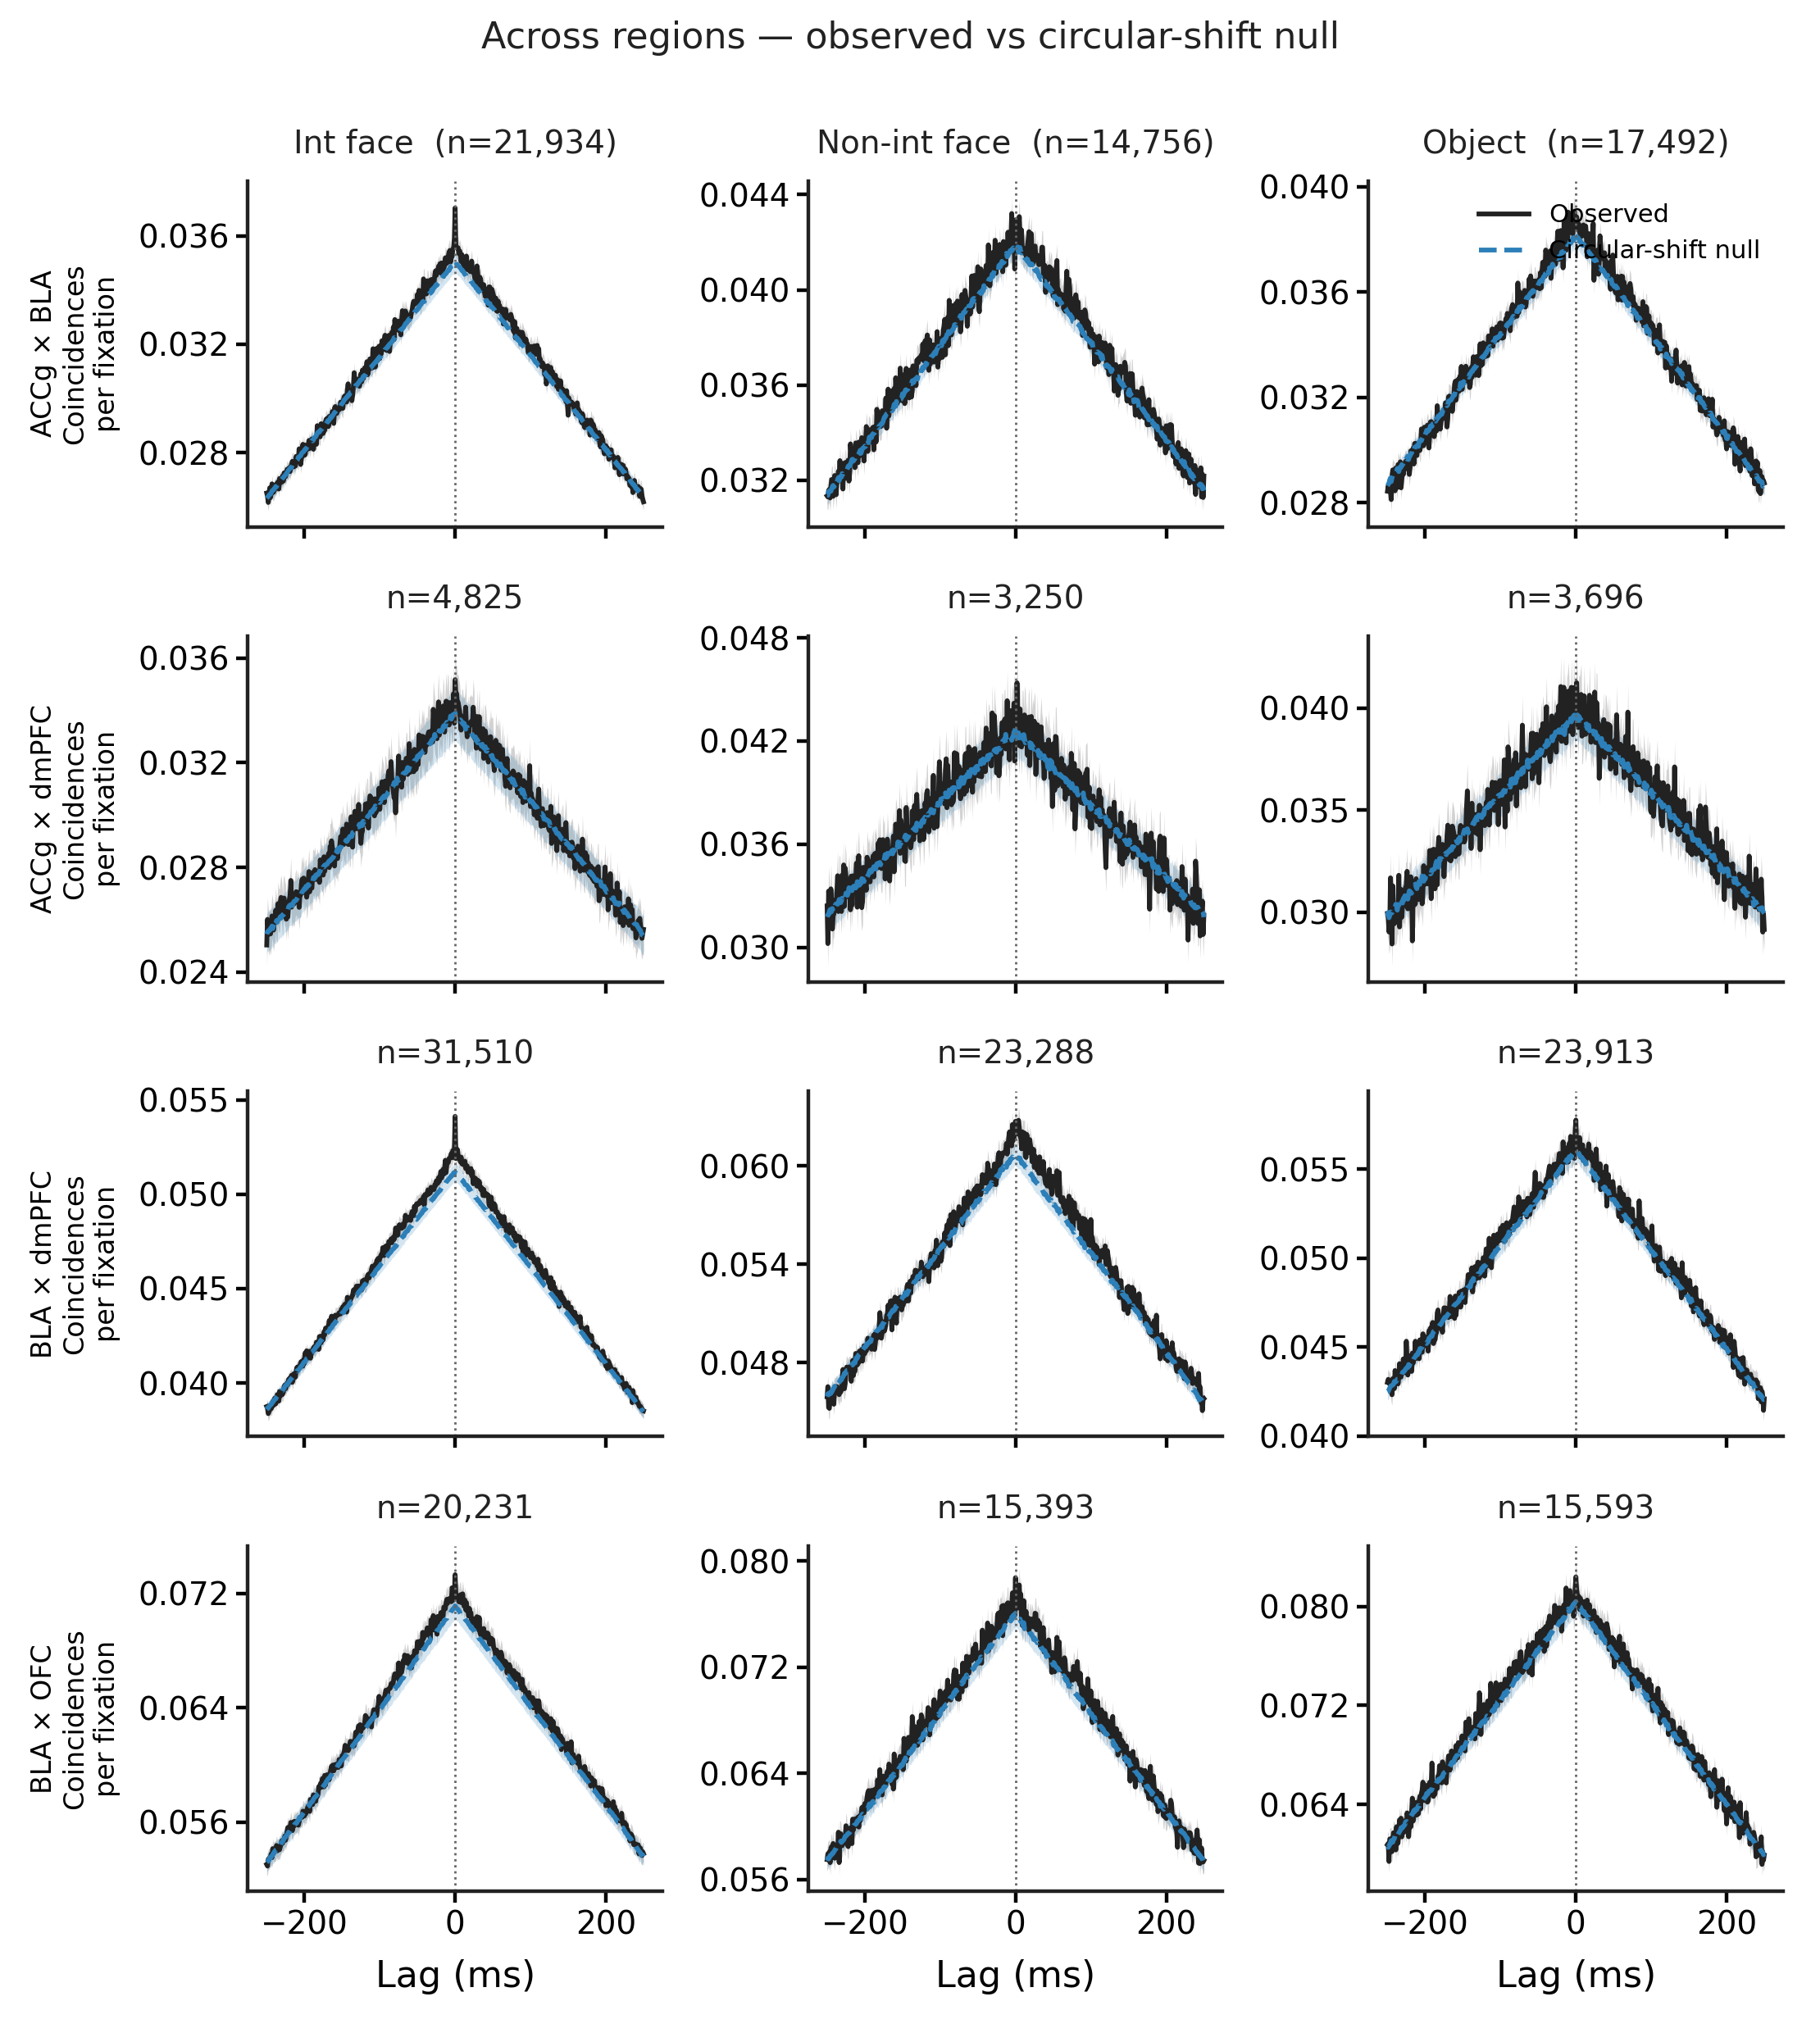

In [8]:
fig, paths = viz.plot_observed_and_null_grid(
    traces, figs, scope="cross_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

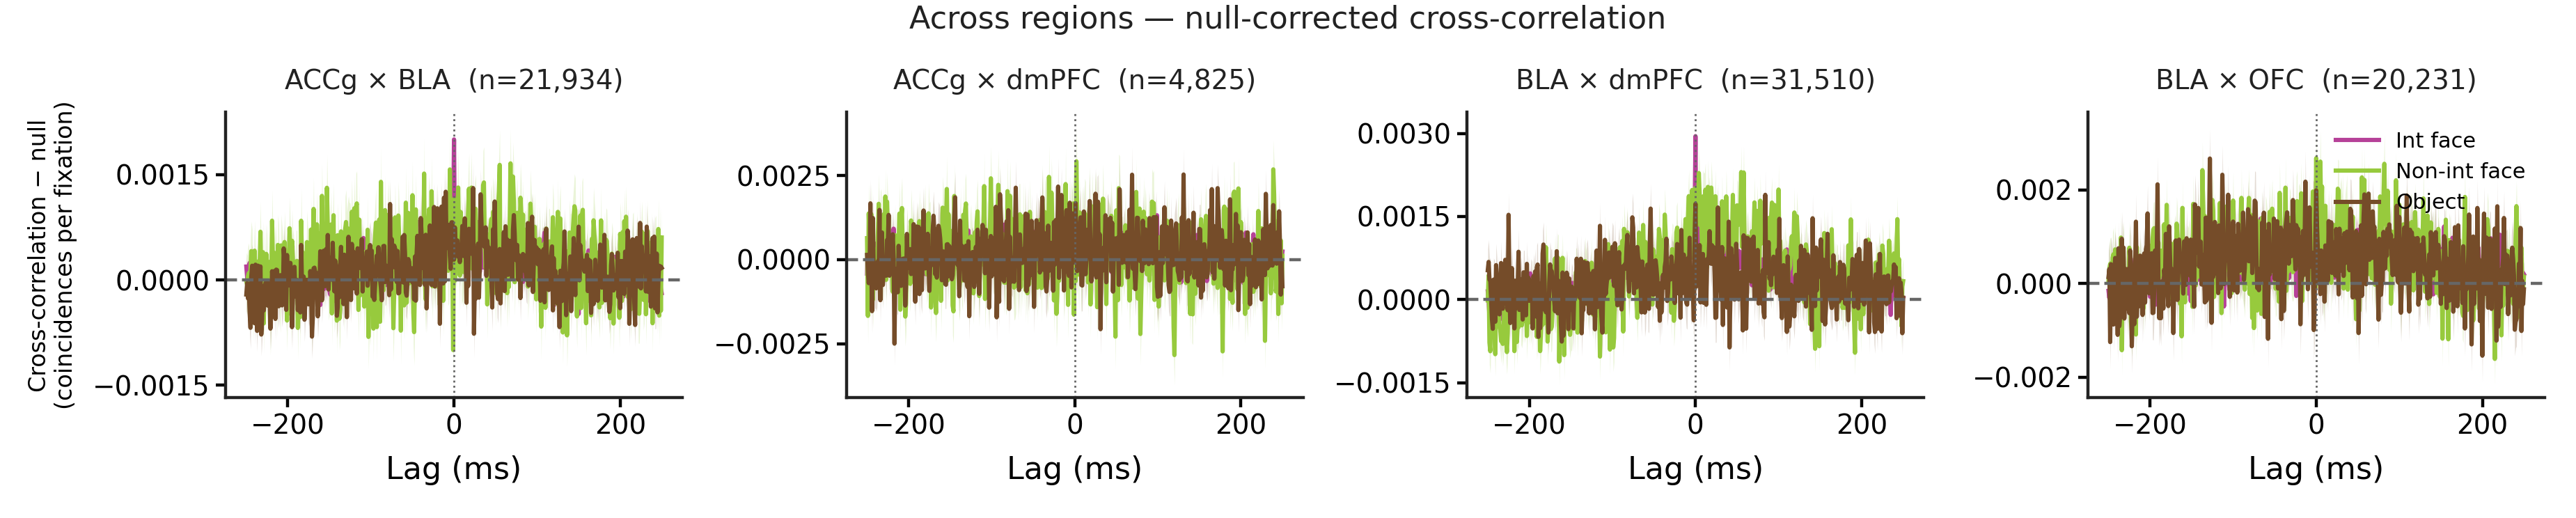

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,14686,0.0007,0.0005,0.0002,50826094.5,0.0000,0.0749,0.0000,True,fdr_bh
1,cross_region,accg-bla,face_interactive,object,17364,0.0007,0.0005,0.0002,72579031.5,0.0000,0.0408,0.0000,True,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,12777,0.0005,0.0005,-0.0000,39721481.0,0.0087,-0.0400,0.0137,True,fdr_bh
3,cross_region,accg-dmpfc,face_interactive,face_non_interactive,3227,0.0003,0.0005,-0.0002,2551933.0,0.3235,0.0567,0.3640,False,fdr_bh
4,cross_region,accg-dmpfc,face_interactive,object,3669,0.0004,0.0004,0.0001,3282108.0,0.1895,0.0412,0.2325,False,fdr_bh
5,cross_region,accg-dmpfc,face_non_interactive,object,2821,0.0005,0.0005,0.0001,1962617.0,0.5235,0.0018,0.5654,False,fdr_bh
6,cross_region,bla-dmpfc,face_interactive,face_non_interactive,23102,0.0013,0.0015,-0.0001,127356974.0,0.0000,0.0653,0.0000,True,fdr_bh
7,cross_region,bla-dmpfc,face_interactive,object,23786,0.0014,0.0005,0.0008,128369211.5,0.0000,0.0925,0.0000,True,fdr_bh
8,cross_region,bla-dmpfc,face_non_interactive,object,19209,0.0017,0.0006,0.0011,90528719.5,0.0258,-0.0025,0.0367,True,fdr_bh
9,cross_region,bla-ofc,face_interactive,face_non_interactive,15352,0.0009,0.0011,-0.0002,56544353.0,0.0000,0.0650,0.0000,True,fdr_bh


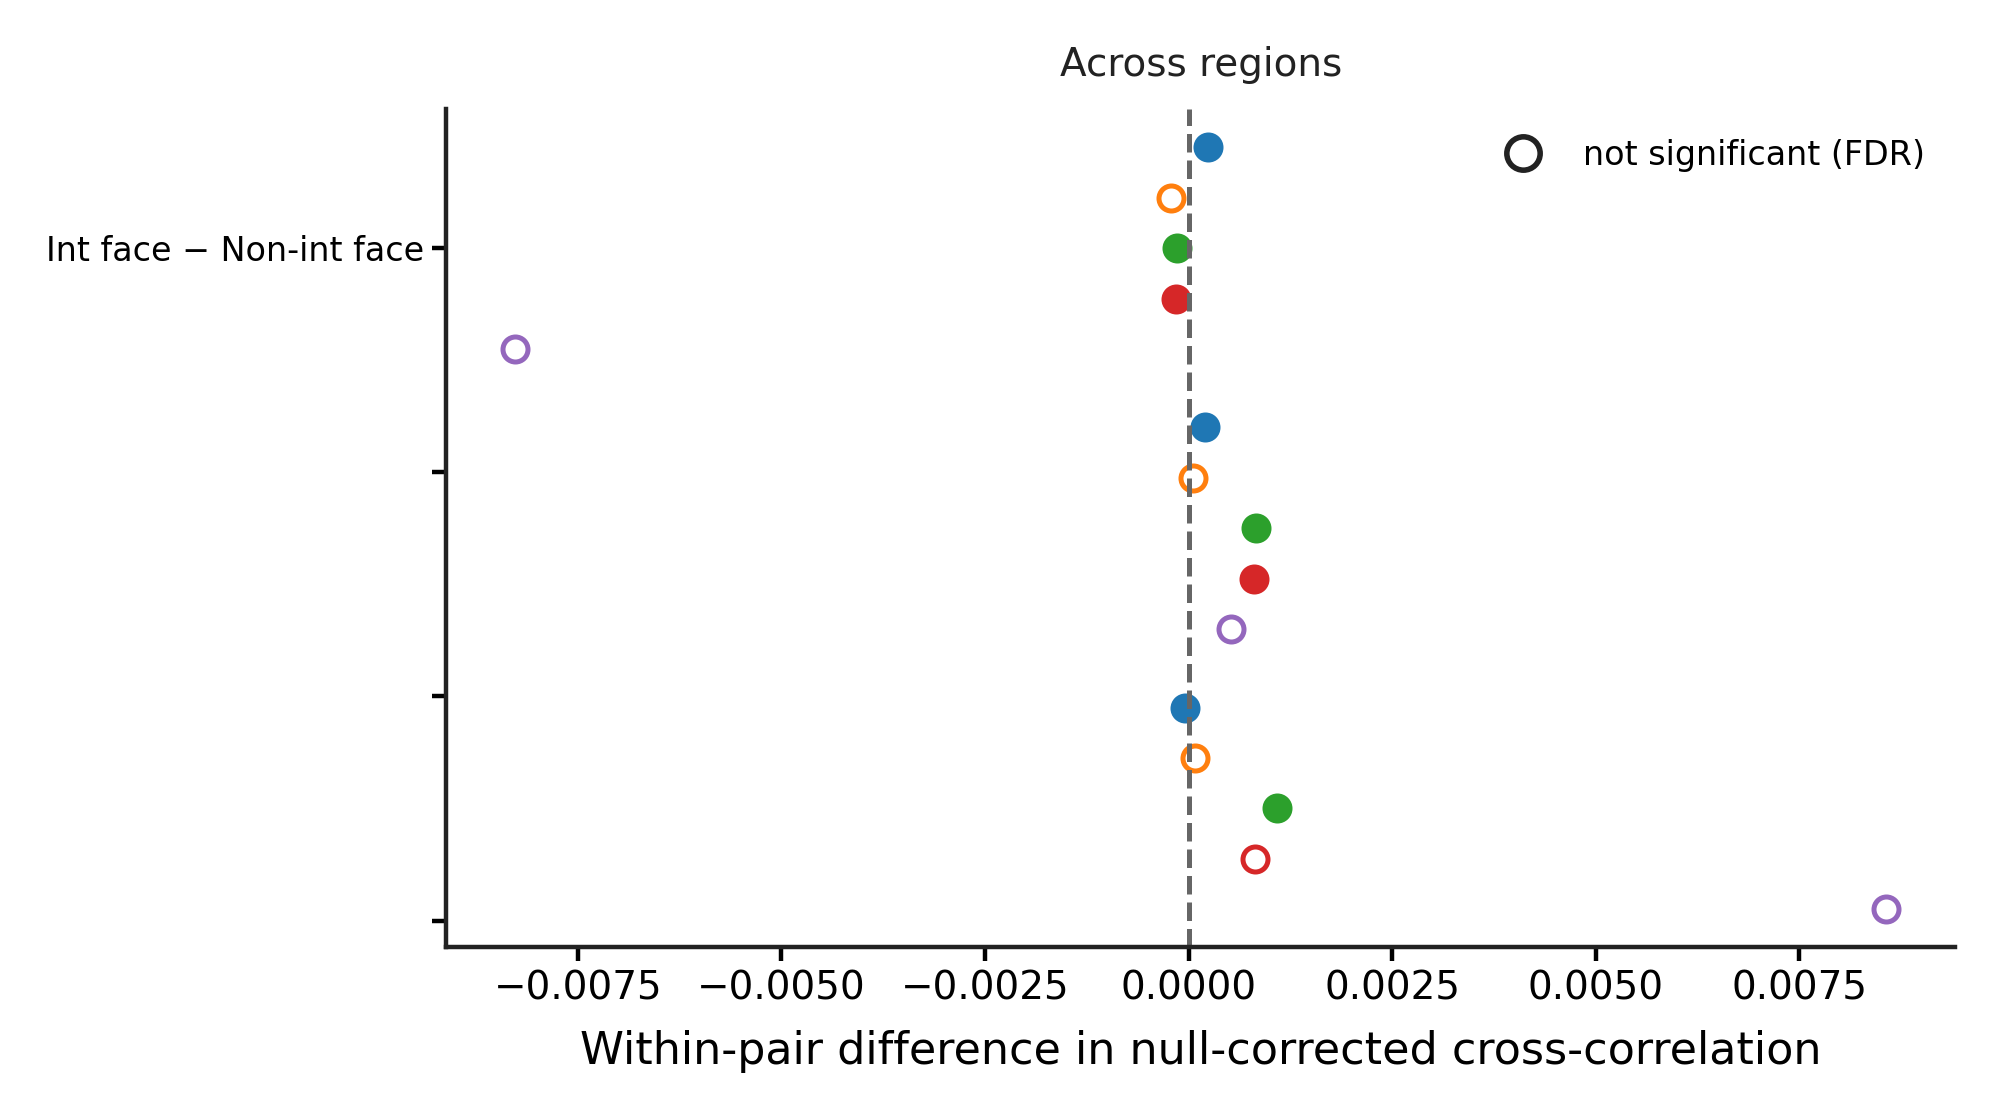

In [9]:
fig, paths = viz.plot_null_corrected_grid(
    traces, figs, scope="cross_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

subset = contrasts.loc[contrasts["scope"] == "cross_region"]
display(subset.round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts, figs, scope="cross_region"
)
display(Image(filename=str(paths["png"])))

# 4. Across regions — FDR-selective pairs

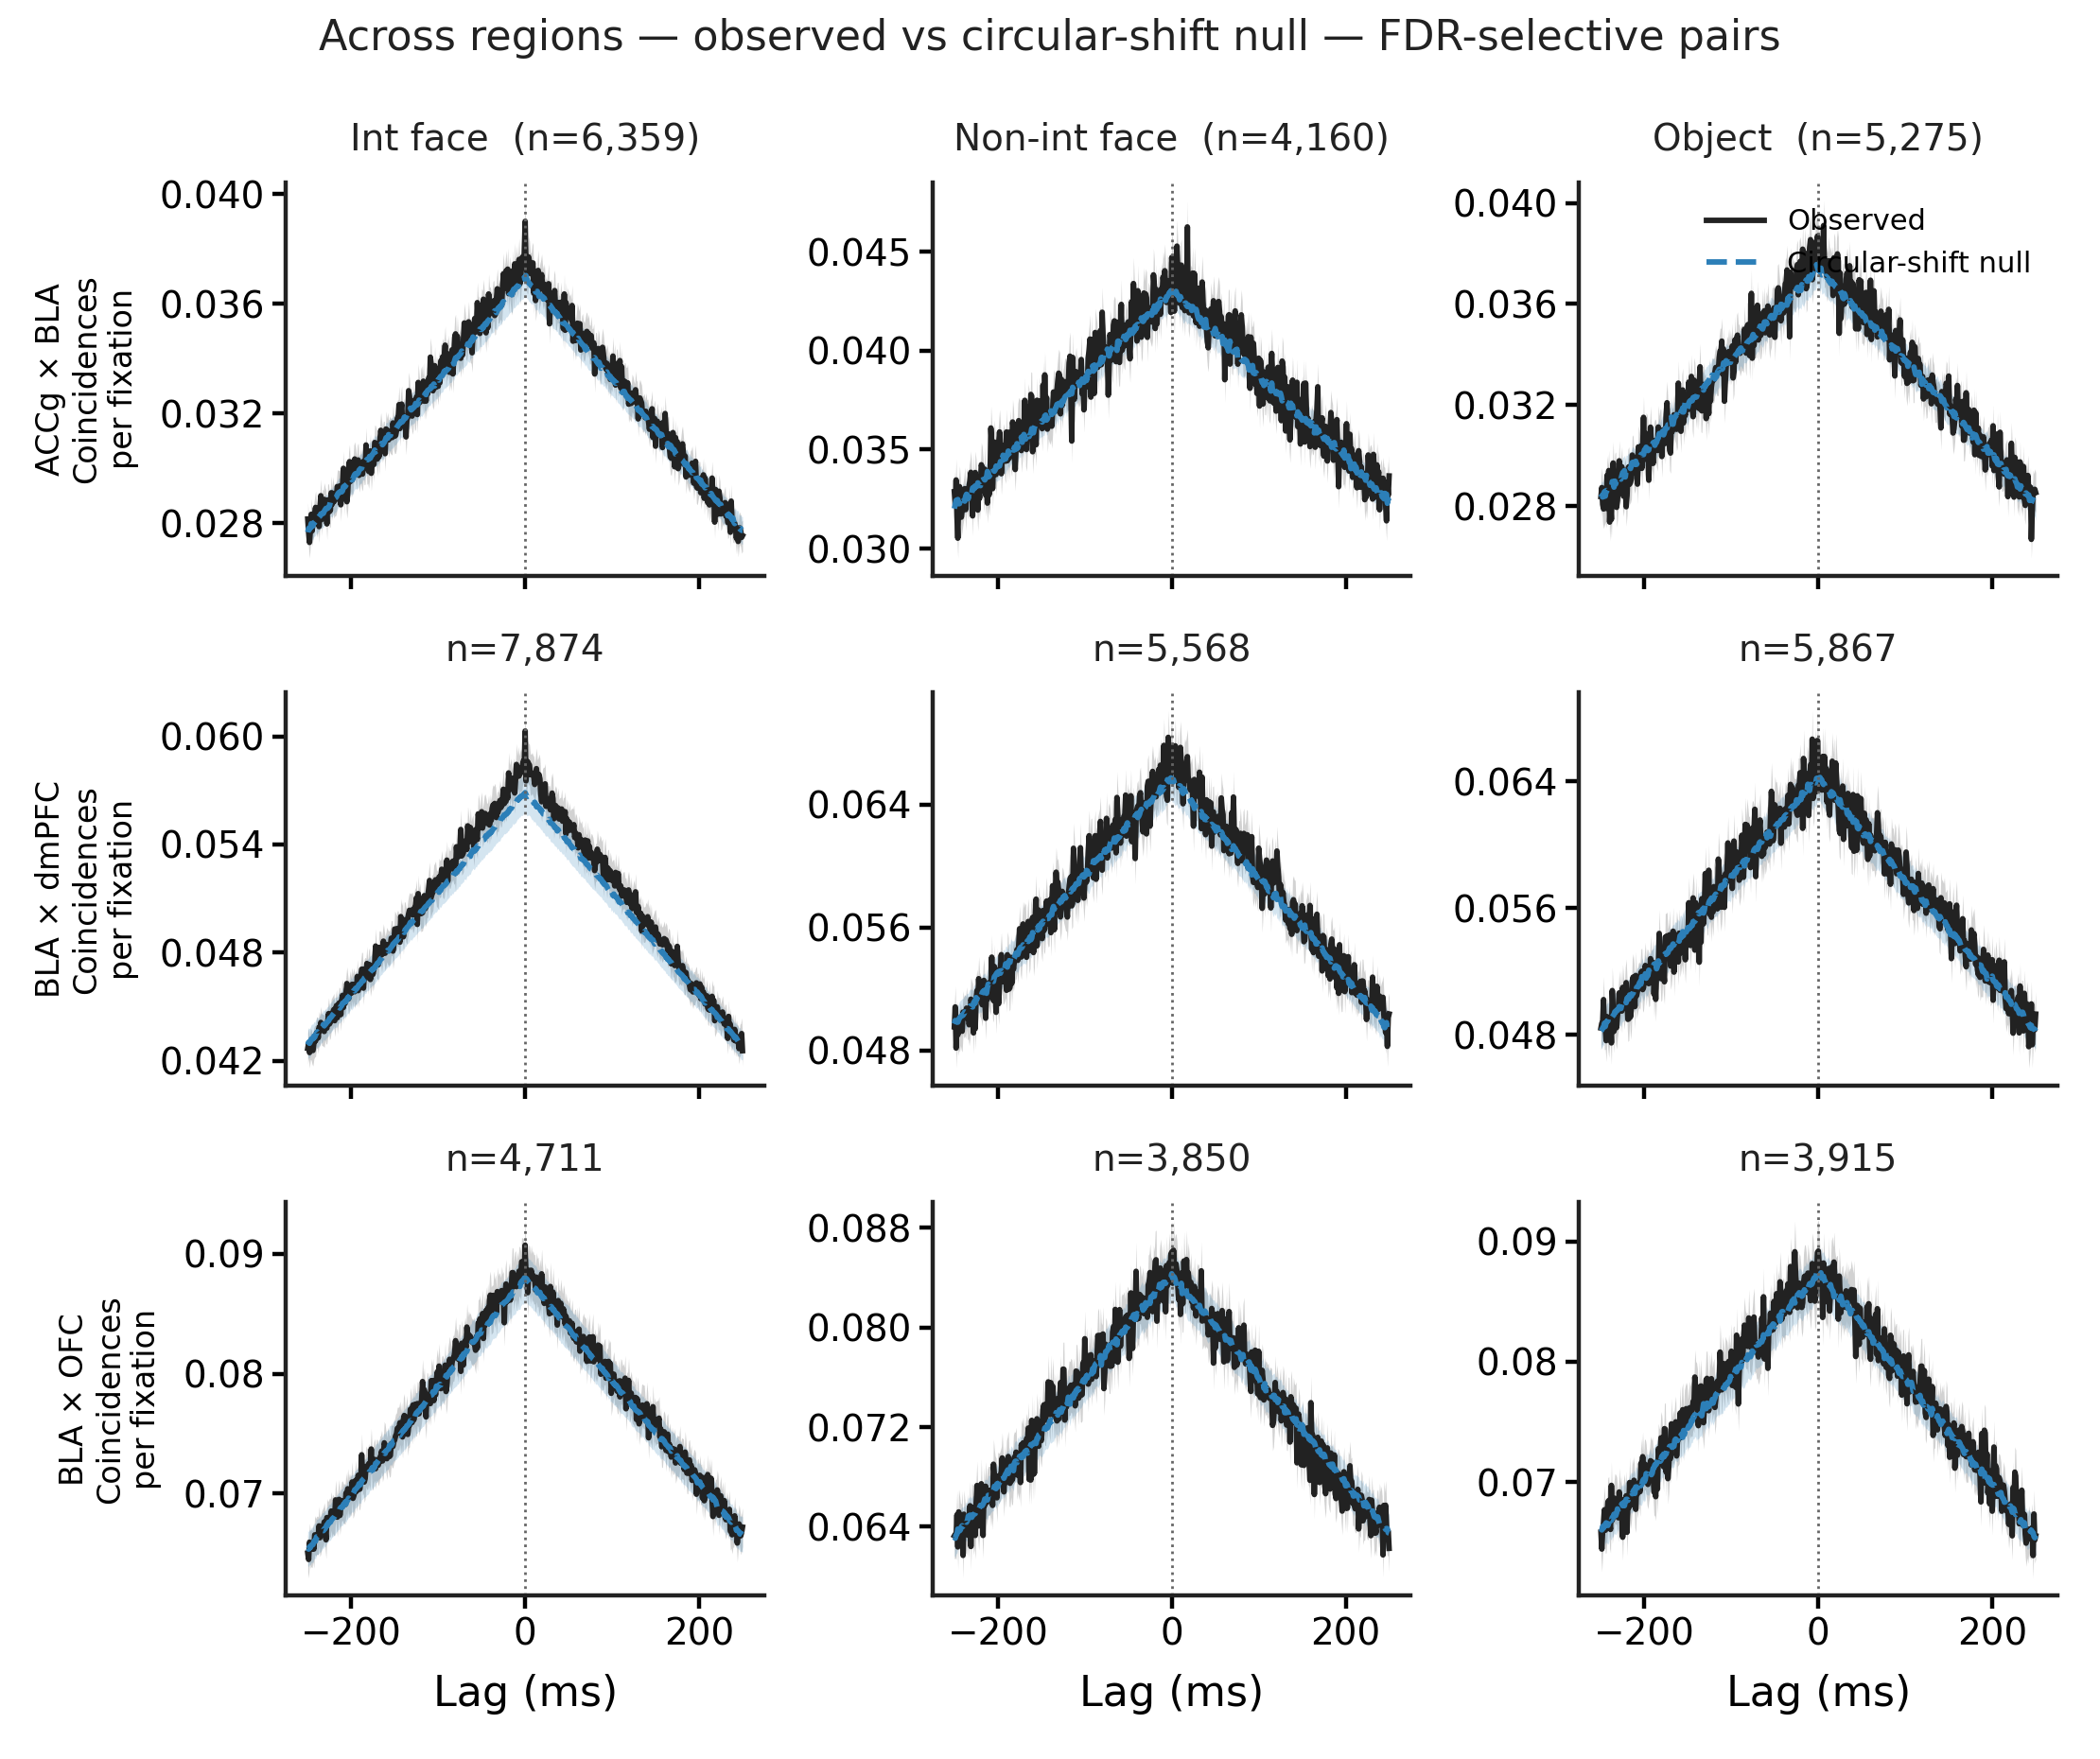

In [10]:
fig, paths = viz.plot_observed_and_null_grid(
    traces_sig, figs, scope="cross_region", min_pairs=MIN_PAIRS, label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

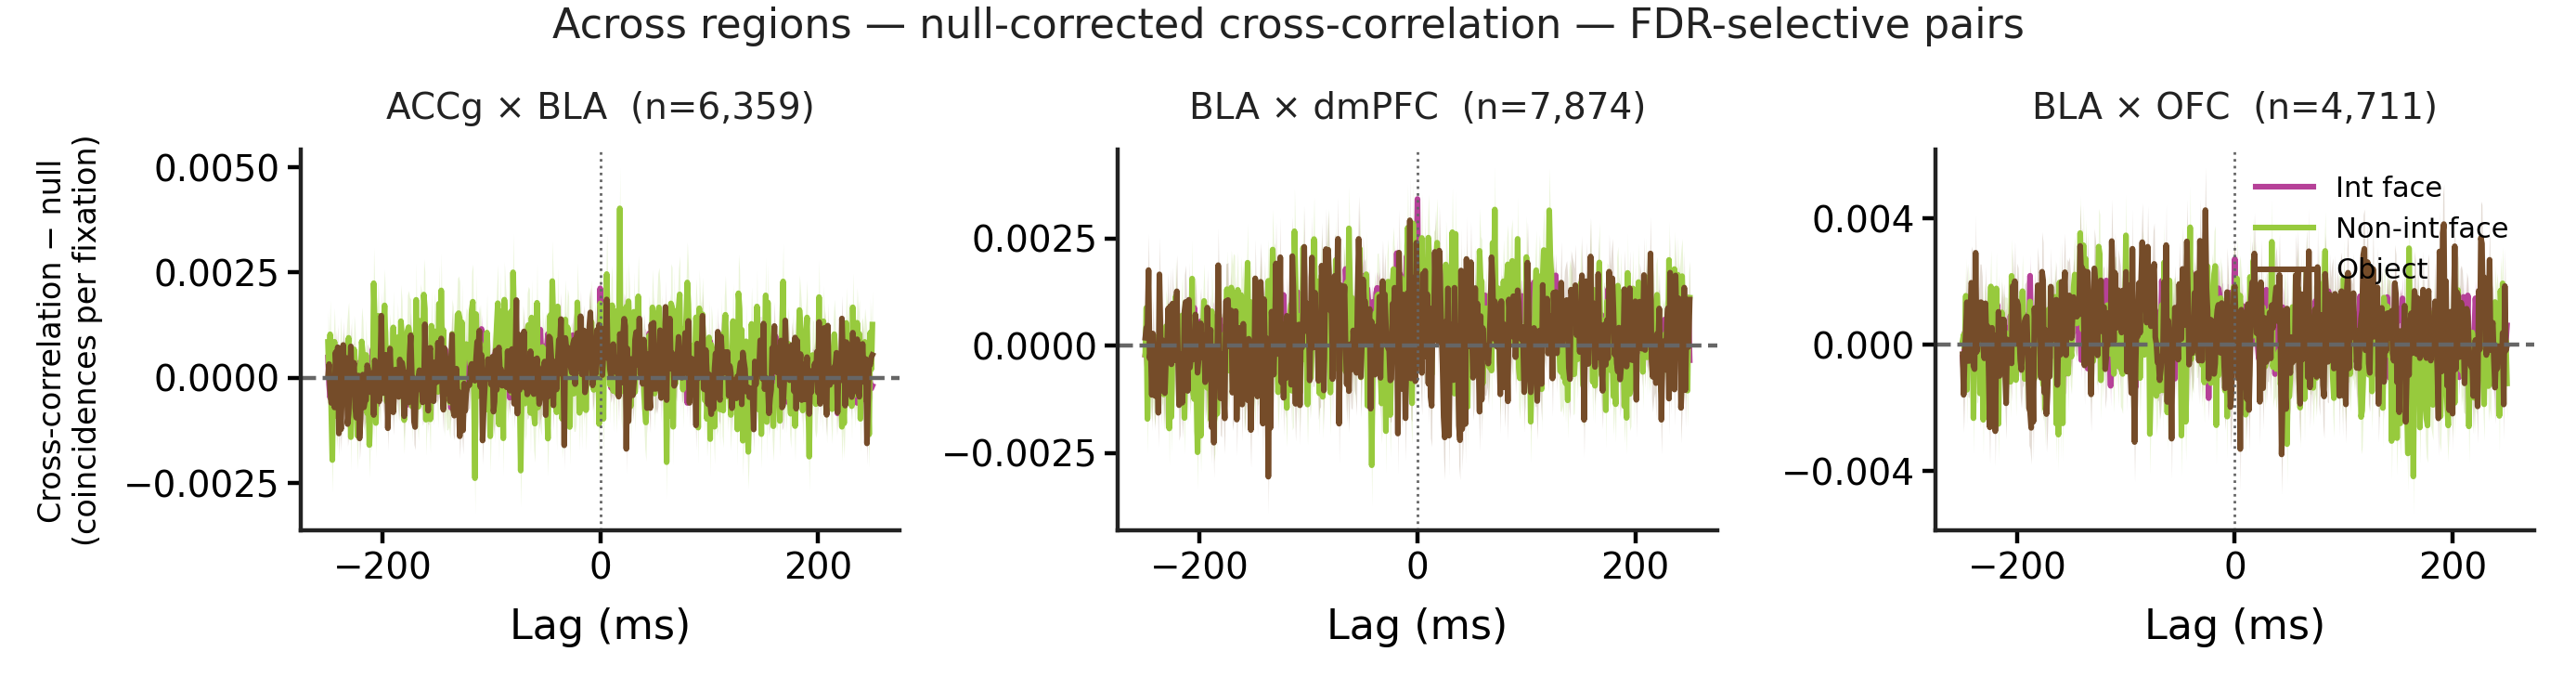

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,4139,0.0008,0.0007,0.0001,4070865.0,0.0056,0.0814,0.0122,True,fdr_bh
1,cross_region,accg-bla,face_interactive,object,5234,0.0007,0.0007,0.0001,6743817.5,0.3434,0.0277,0.4120,False,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,3665,0.0007,0.0008,-0.0001,3215644.5,0.0253,-0.0668,0.0442,True,fdr_bh
3,cross_region,accg-dmpfc,face_interactive,face_non_interactive,168,0.0004,-0.0005,0.0009,5696.0,0.0264,0.2262,0.0442,True,fdr_bh
4,cross_region,accg-dmpfc,face_interactive,object,220,0.0004,-0.0006,0.0011,10516.0,0.0829,0.1545,0.1244,False,fdr_bh
5,cross_region,accg-dmpfc,face_non_interactive,object,135,-0.0005,-0.0009,0.0004,4490.0,0.8262,-0.0370,0.8262,False,fdr_bh
6,cross_region,bla-dmpfc,face_interactive,face_non_interactive,5524,0.0019,0.0010,0.0009,7045941.5,0.0000,0.0862,0.0000,True,fdr_bh
7,cross_region,bla-dmpfc,face_interactive,object,5836,0.0020,0.0007,0.0013,7635580.0,0.0000,0.0987,0.0000,True,fdr_bh
8,cross_region,bla-dmpfc,face_non_interactive,object,4584,0.0012,0.0007,0.0005,5222690.5,0.7234,-0.0236,0.7548,False,fdr_bh
9,cross_region,bla-ofc,face_interactive,face_non_interactive,3847,0.0009,0.0004,0.0005,3549095.5,0.0276,0.0393,0.0442,True,fdr_bh


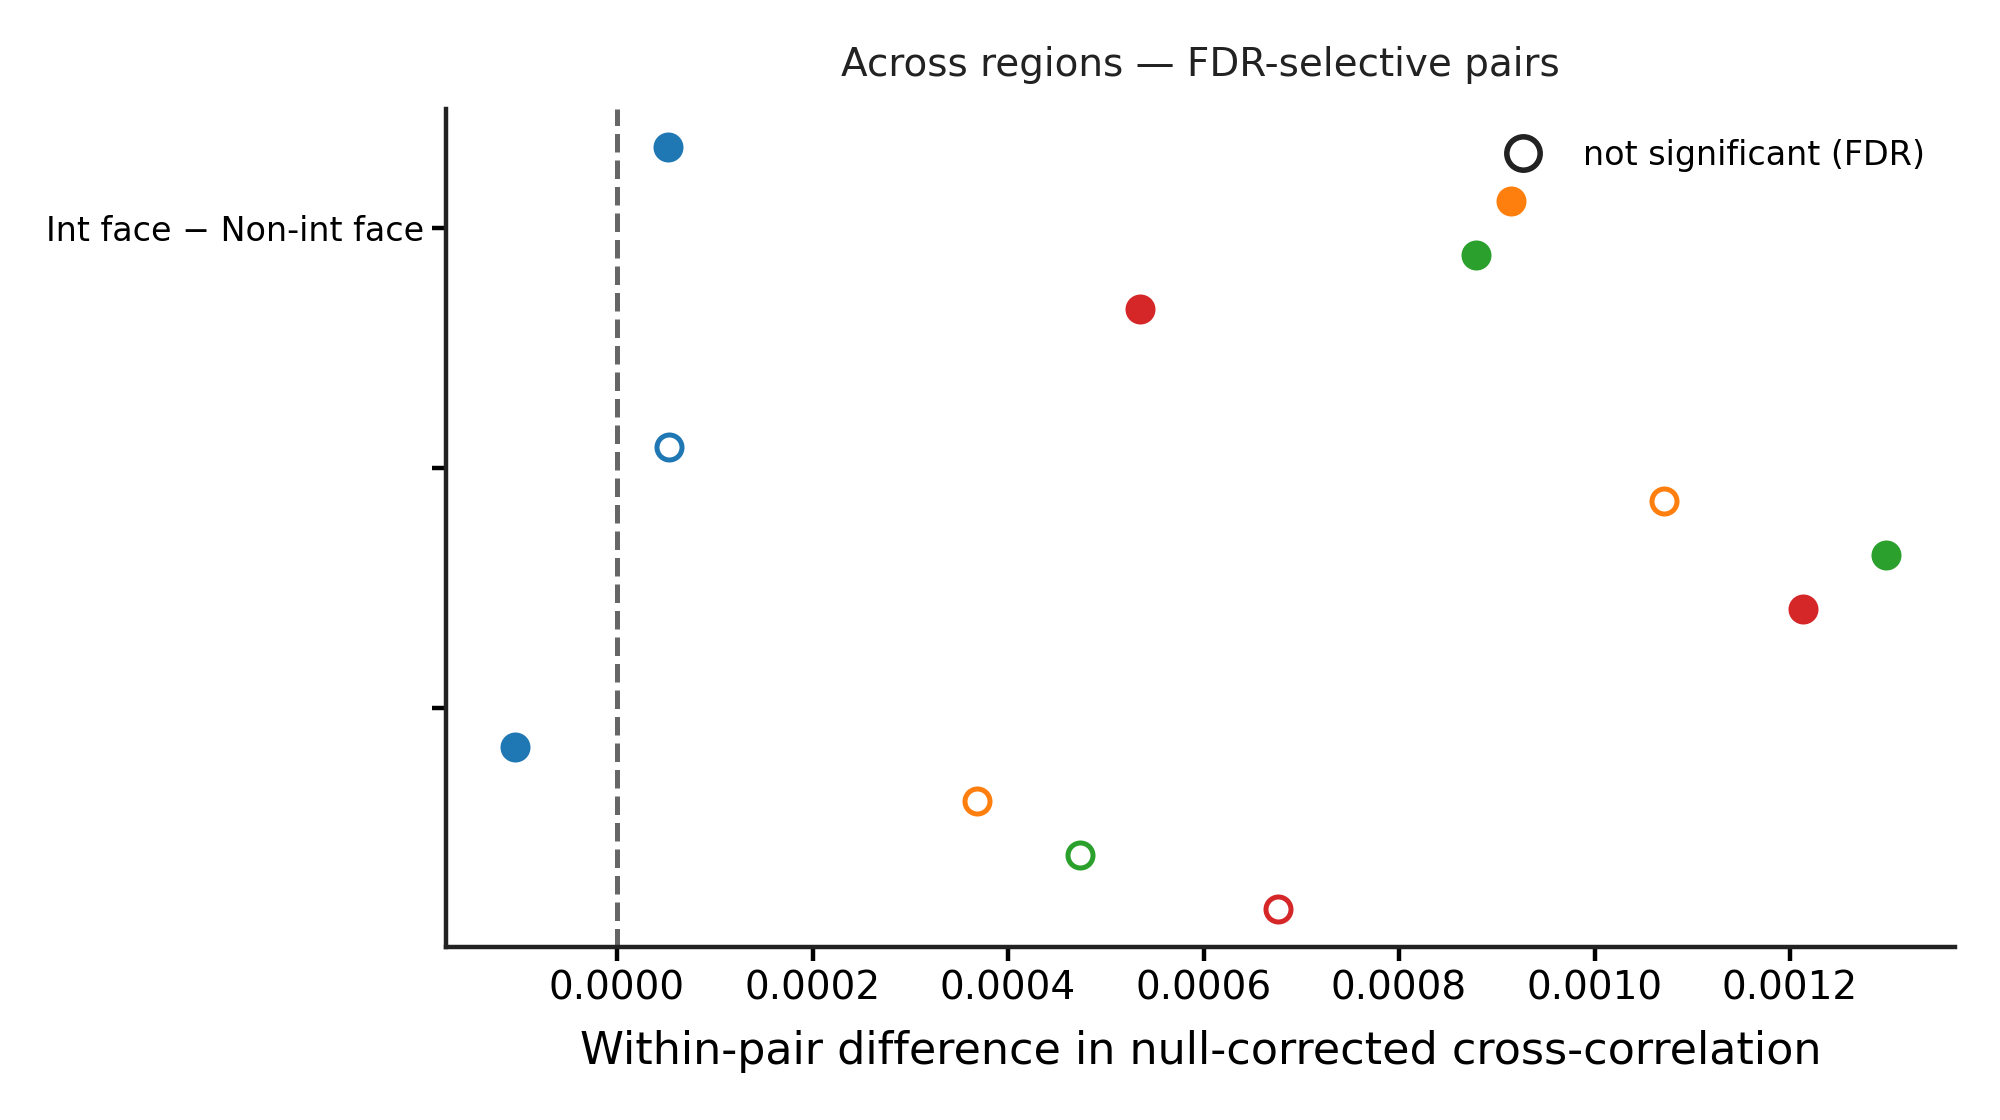

In [11]:
fig, paths = viz.plot_null_corrected_grid(
    traces_sig, figs, scope="cross_region", min_pairs=MIN_PAIRS, label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

subset = contrasts_sig.loc[contrasts_sig["scope"] == "cross_region"]
display(subset.round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts_sig, figs, scope="cross_region", label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

# Supporting

## Is there coordination above null at all?

Secondary to the condition comparison, but worth confirming there is something
to compare. One-sample Wilcoxon of the per-pair excess against zero, per region
and condition, using `z` — the right quantity for this question and the wrong
one for comparing conditions, since it scales with the square root of the
fixation count.

In [12]:
display(pd.read_csv(SUMMARY_DIR / "vs_null_by_region.csv").round(4))

,scope,region_pair,condition,n_pairs,mean_excess,median_excess,statistic,p_value
0,cross_region,accg-bla,face_interactive,21934,0.0437,0.0023,128725011.0,0.0000
1,cross_region,accg-bla,face_non_interactive,14756,0.0260,-0.0229,55154469.0,0.0581
2,cross_region,accg-bla,object,17492,0.0317,-0.0066,80414794.0,0.0000
3,cross_region,accg-dmpfc,face_interactive,4825,0.0398,0.0000,6253367.0,0.0000
4,cross_region,accg-dmpfc,face_non_interactive,3250,0.0275,-0.0204,2717774.0,0.0568
5,cross_region,accg-dmpfc,object,3696,0.0235,-0.0153,3515763.0,0.0462
6,cross_region,bla-dmpfc,face_interactive,31510,0.0569,0.0119,275339664.0,0.0000
7,cross_region,bla-dmpfc,face_non_interactive,23288,0.0340,-0.0149,140852070.0,0.0000
8,cross_region,bla-dmpfc,object,23913,0.0246,-0.0185,144450601.0,0.0369
9,cross_region,bla-ofc,face_interactive,20231,0.0418,0.0065,109973672.0,0.0000


## The zero-lag artifact

Two randomly sampled neurons are essentially never monosynaptically connected,
so a sharp zero-lag peak shared by most pairs on a day is common input —
movement, arousal, or a shared reference/ground artifact. It is a property of
the **day and array**, not of the pair, so flagged days are removed from every
result above rather than noted here.

**1 date(s) removed from every result above:** ['9292018']

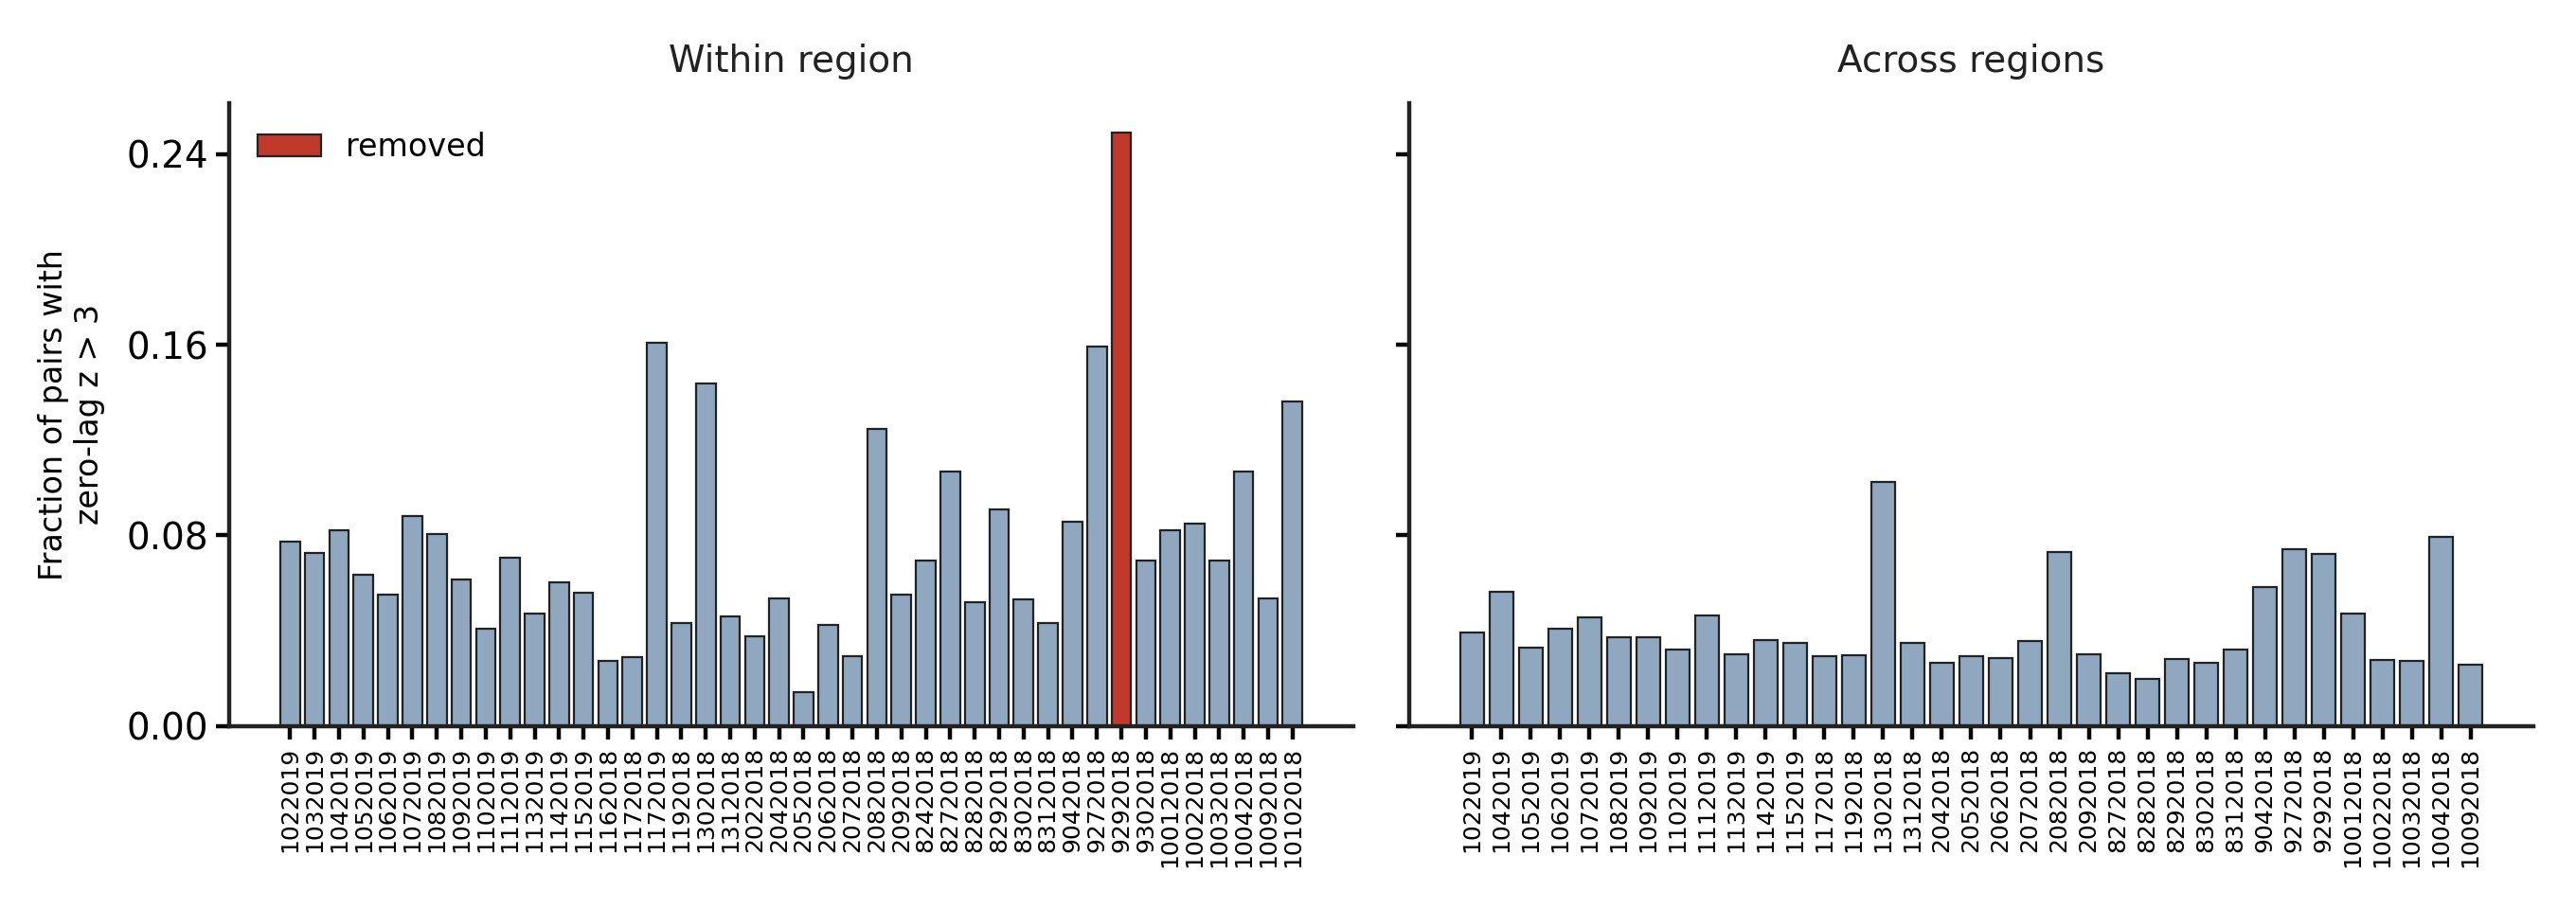

In [13]:
dropped = pd.read_csv(SUMMARY_DIR / "dropped_artifact_dates.csv")
if len(dropped):
    display(Markdown(
        f"**{len(dropped)} date(s) removed from every result above:** "
        f"{sorted(dropped['date'].astype(str))}"
    ))
else:
    display(Markdown("_No date was flagged._"))

diagnostics = pd.read_csv(SUMMARY_DIR / "zero_lag_diagnostics.csv")
fig, paths = viz.plot_zero_lag_diagnostics(diagnostics, figs)
display(Image(filename=str(paths["png"])))